# Time Series Forecasting Refresher — BTC Hourly Returns

End-to-end workflow refresher covering classical and ML approaches to forecasting **BTC hourly log returns** at horizon H=24.

**Forecast target**: $r_t = \ln(p_t / p_{t-1})$ — log returns are (approximately) stationary and additive.

**Evaluation**: rolling 1-step-ahead RMSE, MAE, and directional accuracy on a 30-day held-out test window.

**Sections** (each major section ends with hands-on **Exercises** with hidden solutions):
1. Setup & imports
2. Data loading & sanity
3. EDA
4. Stationarity tests
5. Decomposition
6. Train/test split
7. Naive baselines
8. ETS
9. SARIMA
10. Lag-feature engineering
11. ML model + Optuna
12. Recursive multi-step
13. Feature importance
14. Model comparison
15. Diagnostics
16. Probabilistic forecast (quantile LightGBM)
17. Deployment (joblib + FastAPI)


## 1. Setup & Imports

Standard scientific Python stack plus `statsmodels` (classical), `xgboost`/`lightgbm` (ML), `optuna` (HPO), `shap` (interpretability), `joblib` (serialization).

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import scipy.stats as stats

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error

import xgboost as xgb
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

import joblib

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print("Setup OK")

Setup OK


## Problem Framing

**Why log returns, not price?**
- Prices are explosively non-stationary; classical methods (ARIMA, ETS) assume stationarity.
- Log returns have constant unconditional mean (~0), bounded support in practice, and are additive: $\sum r_t = \ln(p_T/p_0)$.

**Why short horizon (1-step) eval?**
- Cumulative error compounds quickly in volatile crypto. 1-step-ahead RMSE/MAE is the cleanest, least gameable metric.
- We **also** demonstrate recursive multi-step h=1..24.

**Realistic expectations**: Hourly crypto returns are essentially a random walk. We expect RMSE differences across models to be small. A directional accuracy (dir-acc) of 49–53% is realistic; >55% would be suspicious.

## 2. Data Loading & Sanity Checks

Load the shared parquet, filter to BTC, set a `DatetimeIndex` with hourly frequency, and verify continuity.

In [2]:
DATA_PATH = "/home/zlac116/Code/learning/ml-revision/data/crypto_hourly.parquet"

raw = pd.read_parquet(DATA_PATH)
print("All symbols:", raw["symbol"].unique())
print("Raw shape:", raw.shape)

btc = (raw[raw["symbol"] == "BTC"]
       .copy()
       .sort_values("ts")
       .drop_duplicates(subset="ts"))

# UTC index, hourly frequency
btc["ts"] = pd.to_datetime(btc["ts"], utc=True)
btc = btc.set_index("ts")
btc.index = btc.index.tz_convert("UTC")

# Reindex to a strict hourly grid and forward-fill tiny gaps
full_idx = pd.date_range(btc.index.min(), btc.index.max(), freq="H", tz="UTC")
btc = btc.reindex(full_idx)
btc.index.name = "ts"

print("After reindex:", btc.shape)
print("NaNs before ffill:", btc[["close"]].isna().sum().item())
btc[["open", "high", "low", "close", "volume"]] = (
    btc[["open", "high", "low", "close", "volume"]].ffill()
)
btc["symbol"] = "BTC"
print("NaNs after ffill:", btc[["close"]].isna().sum().item())
btc.head()

All symbols: ['BNB' 'BTC' 'ETH' 'SOL']
Raw shape: (70080, 7)
After reindex: (17520, 6)
NaNs before ffill: 0
NaNs after ffill: 0


,open,high,low,close,volume,symbol
ts,,,,,,
2024-04-19 23:00:00+00:00,64012.49,64124.00,62953.90,63818.01,2825.31770,BTC
2024-04-20 00:00:00+00:00,63818.01,64263.41,63418.00,63444.51,2107.44280,BTC
2024-04-20 01:00:00+00:00,63444.51,63777.03,63090.07,63656.00,1283.85296,BTC
2024-04-20 02:00:00+00:00,63656.00,64092.29,63530.00,63834.02,882.54344,BTC
2024-04-20 03:00:00+00:00,63834.01,64040.67,63766.00,63956.00,634.11376,BTC


In [3]:
# Compute log return — our target variable
btc["log_return"] = np.log(btc["close"]).diff()
btc = btc.dropna(subset=["log_return"])
print(f"Final shape: {btc.shape}")
print(f"Period: {btc.index.min()} -> {btc.index.max()}")
print(f"Log return summary:\n{btc['log_return'].describe()}")

Final shape: (17519, 7)
Period: 2024-04-20 00:00:00+00:00 -> 2026-04-19 22:00:00+00:00
Log return summary:
count    17519.000000
mean         0.000009
std          0.005056
min         -0.050195
25%         -0.002078
50%          0.000030
75%          0.002212
max          0.049047
Name: log_return, dtype: float64


### Exercises — Data Loading

**Before you start — techniques you'll use:**

- **Drop dup timestamps first**: `raw.drop_duplicates(subset='ts')` — upstream
  providers emit duplicates on venue failovers.
- **Longest raw gap**: `diff = raw_btc['ts'].sort_values().diff()`, then
  `diff.max()` (a `Timedelta`) or `diff.idxmax()` for position. Divide by
  `pd.Timedelta(hours=1)` for a float.
- **Continuity assertions**: `idx.is_monotonic_increasing`, `not idx.has_duplicates`,
  and `len(idx) == len(pd.date_range(min, max, freq='H', tz='UTC'))`.
- **Dataset summary**: `n_hours = len(df); n_days = n_hours / 24` — put start, end,
  hours, and days in a single `print(f'...')` block.

*Mini-example (continuity asserts):*
```python
expected = pd.date_range(btc.index.min(), btc.index.max(), freq='H', tz='UTC')
assert btc.index.equals(expected), 'index is not a continuous hourly grid'
```


**Worked example — gap finding and continuity assertions**

Demonstrates the four idioms: dropping duplicate timestamps, finding the longest gap as
a `Timedelta`, asserting a continuous hourly grid, and printing a one-line dataset
summary.


In [4]:
import numpy as np, pandas as pd

ts = pd.to_datetime([
    '2024-01-01 00:00', '2024-01-01 01:00',
    '2024-01-01 01:00',                       # duplicate
    '2024-01-01 04:00',                       # 3-hour gap before this
    '2024-01-01 05:00',
], utc=True)
raw = pd.DataFrame({'ts': ts, 'close': [100, 101, 101, 104, 105]})

# 1) Drop duplicates first.
clean = raw.drop_duplicates(subset='ts').sort_values('ts').reset_index(drop=True)
print(f'after dedup: {len(clean)} rows')

# 2) Longest raw gap.
gaps = clean['ts'].diff()
i = int(gaps.idxmax())
print(f'longest gap: {gaps.iloc[i]} between {clean["ts"].iloc[i-1]} and {clean["ts"].iloc[i]}')

# 3) Reindex onto an expected hourly grid; assert it now matches.
expected = pd.date_range(clean['ts'].min(), clean['ts'].max(), freq='1h', tz='UTC')
df = clean.set_index('ts').reindex(expected)
assert df.index.equals(expected), 'still missing'
print(f'continuous index: {len(df)} hourly rows')

# 4) One-line summary.
n_hours = len(df); n_days = n_hours / 24
print(f'\nstart {df.index.min()}  end {df.index.max()}  hours {n_hours}  days {n_days:.1f}')


after dedup: 4 rows


longest gap: 0 days 03:00:00 between 2024-01-01 01:00:00+00:00 and 2024-01-01 04:00:00+00:00
continuous index: 6 hourly rows

start 2024-01-01 00:00:00+00:00  end 2024-01-01 05:00:00+00:00  hours 6  days 0.2


**Exercise 2.1**: Find the **longest gap** (in hours) between consecutive original timestamps in the raw BTC data (before any reindex/ffill). Report start, end, and gap length.

*Expected*: Print of `(start_ts, end_ts, gap_hours)`. For a clean dataset most gaps are 1h.

In [5]:
# Your answer here


**Expected output:**

```text
Gap: 2024-04-19 23:00:00+00:00 -> 2024-04-20 00:00:00+00:00 (1.0h)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
raw_btc = (raw[raw['symbol'] == 'BTC']
           .sort_values('ts')
           .drop_duplicates(subset='ts'))
raw_btc['ts'] = pd.to_datetime(raw_btc['ts'], utc=True)
deltas = raw_btc['ts'].diff()
i_max = deltas.idxmax()
gap_hours = deltas.loc[i_max].total_seconds() / 3600
print('Gap:', raw_btc.loc[i_max - 1, 'ts'], '->', raw_btc.loc[i_max, 'ts'],
      f'({gap_hours:.1f}h)')
```

**Explanation**: Compute consecutive timestamp deltas with `.diff()`, take `idxmax()` to find the largest gap, and print neighbours. This catches exchange outages or missing-bar issues that ffill silently hides.

</details>

**Exercise 2.2**: Verify the post-reindex BTC index is a **continuous hourly grid** with no gaps and no duplicates. Use one assert per check.

In [6]:
# Your answer here


**Expected output:**

```text
Index continuity: OK
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
assert btc.index.is_monotonic_increasing, 'Index must be sorted ascending'
assert not btc.index.has_duplicates, 'No duplicate timestamps'
expected = pd.date_range(btc.index.min(), btc.index.max(), freq='H', tz='UTC')
assert len(btc) == len(expected), f'Got {len(btc)}, expected {len(expected)}'
assert (btc.index == expected).all(), 'Index must equal expected hourly grid'
print('Index continuity: OK')
```

**Explanation**: Four asserts cover monotonicity, uniqueness, length match, and value-by-value equality with the expected hourly grid. Cheap, deterministic, fail-fast.

</details>

**Exercise 2.3**: Compute the **% of original timestamps that were missing** before the reindex (i.e. gaps that were filled).

In [7]:
# Your answer here


**Expected output:**

```text
Raw rows: 17520, full grid: 17519, % filled: -0.006%
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
raw_btc = raw[raw['symbol'] == 'BTC'].drop_duplicates(subset='ts')
n_raw = len(raw_btc)
n_full = len(btc)
missing_pct = 100 * (n_full - n_raw) / n_full
print(f'Raw rows: {n_raw}, full grid: {n_full}, % filled: {missing_pct:.3f}%')
```

**Explanation**: Compare the count of unique original timestamps to the count after reindexing onto the full hourly grid. Any positive delta is gap-fill — useful for quality reporting and for deciding whether to drop affected windows.

</details>

**Exercise 2.4**: Report the dataset's **start, end, total hours, and approximate total days** in a single print.

In [8]:
# Your answer here


**Expected output:**

```text
Start: 2024-04-20 00:00:00+00:00
End  : 2026-04-19 22:00:00+00:00
Hours: 17519 (730.0 days)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
n_hours = len(btc)
n_days = n_hours / 24
print(f'Start: {btc.index.min()}')
print(f'End  : {btc.index.max()}')
print(f'Hours: {n_hours} ({n_days:.1f} days)')
```

**Explanation**: Quick summary every dataset card needs. Knowing the calendar span up-front shapes downstream choices like CV fold count and seasonal period.

</details>

## 3. Exploratory Data Analysis (Time-Series Specific)

For a return series we look at: level chart, return distribution (fat tails!), rolling statistics, and **ACF/PACF of returns AND squared returns** (volatility clustering).

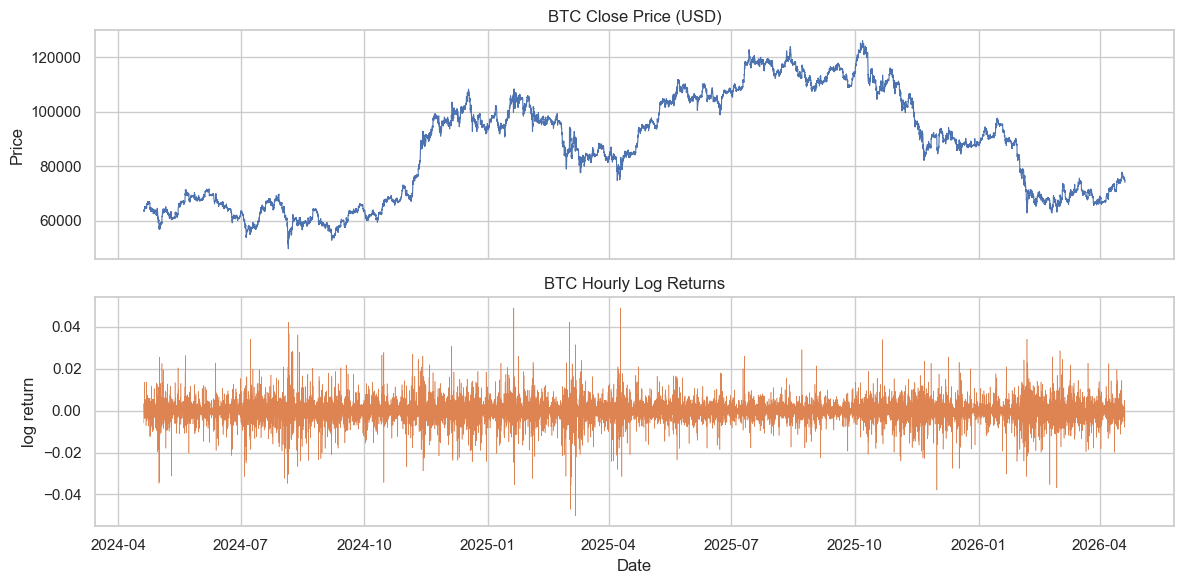

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(btc.index, btc["close"], color="C0", lw=0.8)
axes[0].set_title("BTC Close Price (USD)")
axes[0].set_ylabel("Price")
axes[1].plot(btc.index, btc["log_return"], color="C1", lw=0.4)
axes[1].set_title("BTC Hourly Log Returns")
axes[1].set_ylabel("log return")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

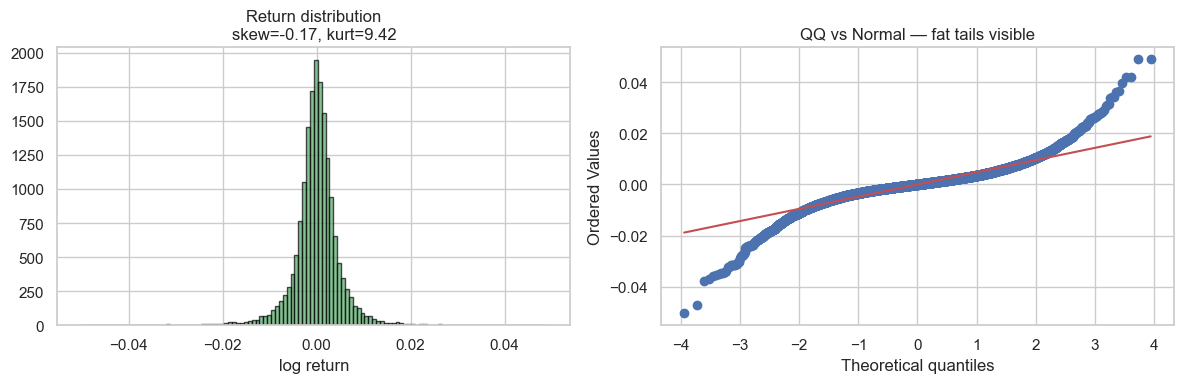

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(btc["log_return"], bins=120, color="C2", edgecolor="black", alpha=0.7)
axes[0].set_title(f"Return distribution\nskew={btc['log_return'].skew():.2f}, "
                  f"kurt={btc['log_return'].kurt():.2f}")
axes[0].set_xlabel("log return")

stats.probplot(btc["log_return"].dropna(), dist="norm", plot=axes[1])
axes[1].set_title("QQ vs Normal — fat tails visible")
plt.tight_layout()
plt.show()

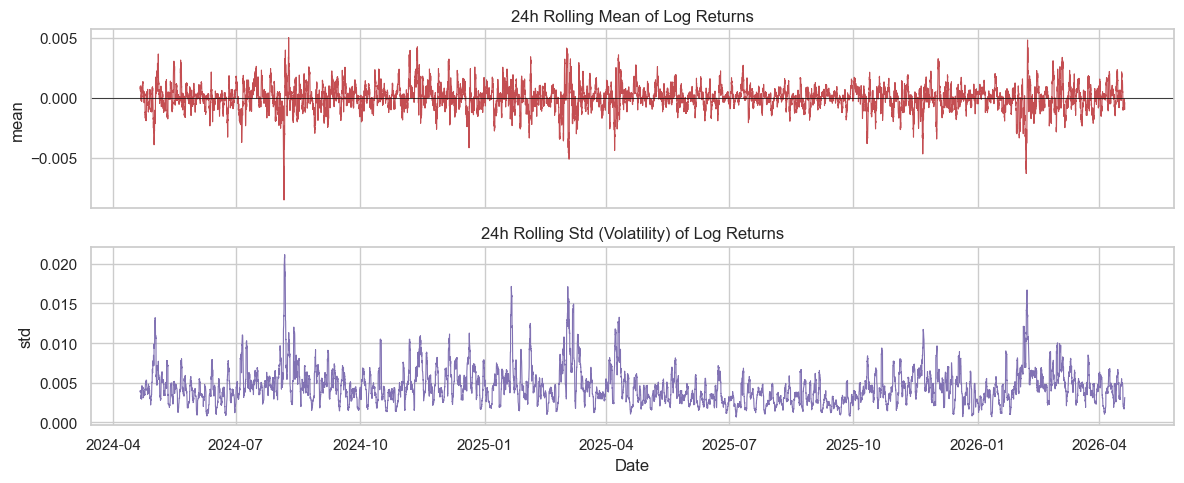

In [11]:
# Rolling mean and volatility (24h window)
rmean = btc["log_return"].rolling(24).mean()
rvol = btc["log_return"].rolling(24).std()

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(rmean.index, rmean, color="C3", lw=0.8)
axes[0].axhline(0, color="black", lw=0.5)
axes[0].set_title("24h Rolling Mean of Log Returns")
axes[0].set_ylabel("mean")

axes[1].plot(rvol.index, rvol, color="C4", lw=0.8)
axes[1].set_title("24h Rolling Std (Volatility) of Log Returns")
axes[1].set_ylabel("std")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

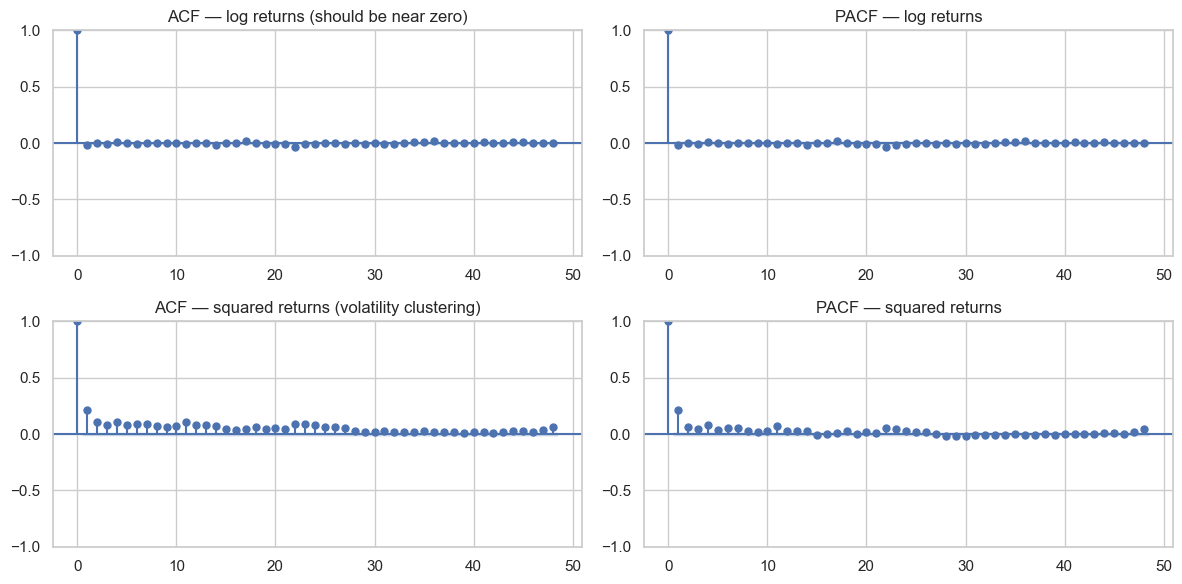

In [12]:
# ACF / PACF of returns and squared returns
fig, axes = plt.subplots(2, 2, figsize=(12, 6))
plot_acf(btc["log_return"].dropna(), lags=48, ax=axes[0, 0])
axes[0, 0].set_title("ACF — log returns (should be near zero)")
plot_pacf(btc["log_return"].dropna(), lags=48, ax=axes[0, 1], method="ywm")
axes[0, 1].set_title("PACF — log returns")

plot_acf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 0])
axes[1, 0].set_title("ACF — squared returns (volatility clustering)")
plot_pacf(btc["log_return"].dropna() ** 2, lags=48, ax=axes[1, 1], method="ywm")
axes[1, 1].set_title("PACF — squared returns")
plt.tight_layout()
plt.show()

### Exercises — EDA

**Before you start — techniques you'll use:**

- **Rolling volatility**: `btc['log_return'].rolling(24*7).std()` — window is rows,
  so scale by the sampling rate.
- **Hurst (R/S)**: chunk the series, for each chunk compute range / std, then
  regress `log(RS)` on `log(chunk_size)`. H ≈ 0.5 = random walk; >0.5 persistent.
- **Intraday boxplot**: `tmp['hour'] = tmp.index.hour` then
  `sns.boxplot(data=tmp, x='hour', y='log_return', showfliers=False)`.
- **Manual autocorrelation**: at lag k, `np.corrcoef(r[:-k], r[k:])[0, 1]`.
  Cross-check with `statsmodels.tsa.stattools.acf` — they should agree to ~1e-10.

*Mini-example (manual ACF):*
```python
r = btc['log_return'].dropna().values
for k in [1, 24, 168]:
    print(f'lag {k:3d}: {np.corrcoef(r[:-k], r[k:])[0, 1]:+.4f}')
```


**Worked example — rolling vol, Hurst, intraday boxplot, manual ACF**

Four self-contained EDA primitives. The Hurst R/S estimator is the only one that's
unfamiliar; read its loop carefully — the exercise asks you to write the same.


rolling 7d vol — last: 0.0104
Hurst exponent: 0.535


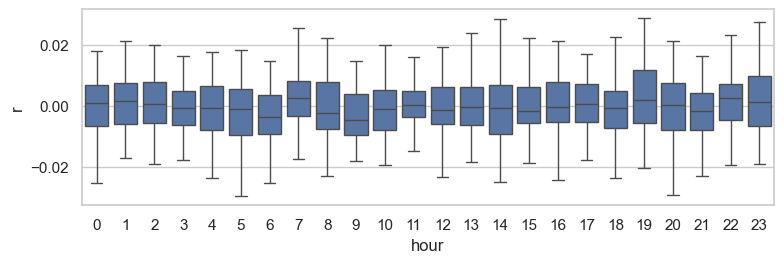

lag   1: +0.0082
lag  24: +0.0448
lag 168: +0.0005


In [13]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*60, freq='1h', tz='UTC')
log_ret = pd.Series(rng.normal(0, 0.01, len(idx)), index=idx)

# 1) 7-day rolling vol.
vol_7d = log_ret.rolling(24*7).std()
print(f'rolling 7d vol — last: {vol_7d.iloc[-1]:.4f}')

# 2) Hurst (R/S) — H~0.5 random walk, >0.5 persistent, <0.5 anti-persistent.
def hurst_rs(x, n_chunks=5):
    x = np.asarray(x); chunk = len(x) // n_chunks
    rs = []
    for i in range(n_chunks):
        seg = x[i*chunk:(i+1)*chunk]
        seg = seg - seg.mean()
        z = np.cumsum(seg)
        rs.append((z.max() - z.min()) / seg.std())
    return float(np.log(np.mean(rs)) / np.log(chunk))

print(f'Hurst exponent: {hurst_rs(log_ret.values):.3f}')

# 3) Hour-of-day boxplot.
tmp = log_ret.to_frame('r'); tmp['hour'] = tmp.index.hour
fig, ax = plt.subplots(figsize=(8, 2.8))
sns.boxplot(data=tmp, x='hour', y='r', showfliers=False, ax=ax)
plt.tight_layout(); plt.show()

# 4) Manual ACF at lags 1, 24, 168 — np.corrcoef on overlapping slices.
r = log_ret.dropna().values
for k in [1, 24, 168]:
    print(f'lag {k:>3}: {np.corrcoef(r[:-k], r[k:])[0, 1]:+.4f}')


**Exercise 3.1**: Plot the **7-day rolling volatility** (std of log returns over a 24*7 window) for the entire history.

In [14]:
# Your answer here


**Expected output:**

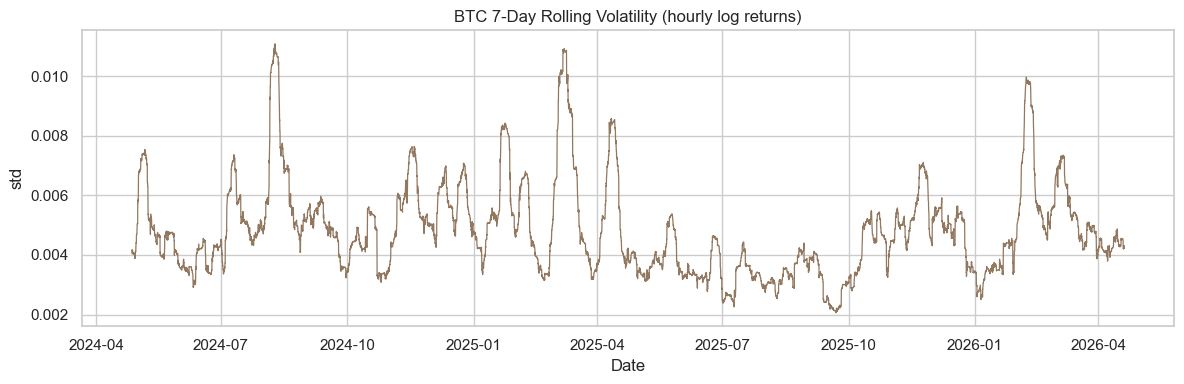

<details>
<summary>💡 Click to reveal solution</summary>

```python
vol_7d = btc['log_return'].rolling(24 * 7).std()
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(vol_7d.index, vol_7d, color='C5', lw=0.9)
ax.set_title('BTC 7-Day Rolling Volatility (hourly log returns)')
ax.set_xlabel('Date')
ax.set_ylabel('std')
plt.tight_layout(); plt.show()
```

**Explanation**: A 168-hour rolling std smooths out intraday noise and reveals macro vol regimes (calm vs stressed). Identifying these regimes matters for vol-targeting strategies and for robust loss design.

</details>

**Exercise 3.2**: Compute the **Hurst exponent** of log returns using a simple R/S estimator on 5 chunks. H ≈ 0.5 = random walk; H < 0.5 = mean reverting; H > 0.5 = trending.

In [15]:
# Your answer here


**Expected output:**

```text
Hurst (R/S, 5 chunks): 0.529
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def hurst_rs(x, n_chunks=5):
    x = np.asarray(x)
    chunk = len(x) // n_chunks
    rs_vals = []
    for i in range(n_chunks):
        seg = x[i * chunk:(i + 1) * chunk]
        z = seg - seg.mean()
        r = z.cumsum().max() - z.cumsum().min()
        s = seg.std(ddof=1)
        if s > 0:
            rs_vals.append(r / s)
    log_n = np.log(chunk)
    log_rs = np.log(np.mean(rs_vals))
    return log_rs / log_n
h = hurst_rs(btc['log_return'].dropna().values)
print(f'Hurst (R/S, 5 chunks): {h:.3f}')
```

**Explanation**: Single-scale R/S is the simplest possible estimator. For BTC hourly returns expect H near 0.5 (random walk). True Hurst estimation needs multi-scale R/S or DFA, but this is enough for a smell test.

</details>

**Exercise 3.3**: Box plot of log returns by **hour-of-day** (0..23). Is there a visible intraday seasonality?

In [16]:
# Your answer here


**Expected output:**

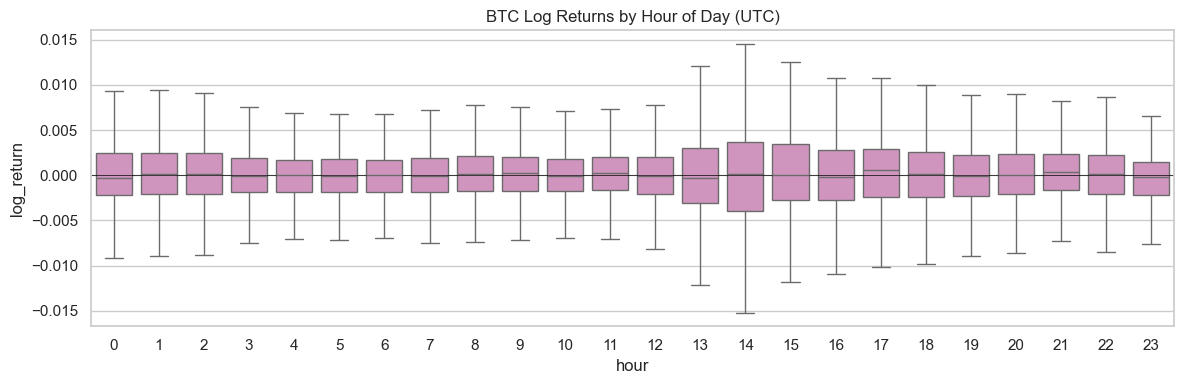

<details>
<summary>💡 Click to reveal solution</summary>

```python
tmp = btc.copy()
tmp['hour'] = tmp.index.hour
fig, ax = plt.subplots(figsize=(12, 4))
sns.boxplot(data=tmp, x='hour', y='log_return', ax=ax,
            showfliers=False, color='C6')
ax.set_title('BTC Log Returns by Hour of Day (UTC)')
ax.axhline(0, color='black', lw=0.5)
plt.tight_layout(); plt.show()
```

**Explanation**: Group by hour-of-day and box-plot. Crypto trades 24/7, so intraday seasonality is much weaker than equities. Any visible pattern is more likely a microstructure artefact (UTC funding times, US open) than tradeable alpha.

</details>

**Exercise 3.4**: Compute the **autocorrelation manually** at lags 1, 24, and 168 using `np.corrcoef` (not statsmodels). Compare to statsmodels' `acf`.

In [17]:
# Your answer here


**Expected output:**

```text
Lag   1: manual=-0.0148  statsmodels=-0.0148
Lag  24: manual=-0.0091  statsmodels=-0.0091
Lag 168: manual=-0.0020  statsmodels=-0.0020
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from statsmodels.tsa.stattools import acf as sm_acf
r = btc['log_return'].dropna().values
for k in [1, 24, 168]:
    rho_manual = np.corrcoef(r[:-k], r[k:])[0, 1]
    rho_sm = sm_acf(r, nlags=k, fft=False)[k]
    print(f'Lag {k:3d}: manual={rho_manual:+.4f}  statsmodels={rho_sm:+.4f}')
```

**Explanation**: Manual lag-k autocorrelation is just `corrcoef(x[:-k], x[k:])`. statsmodels' `acf` divides by N (biased) instead of N-k, so values can differ slightly at long lags. Both should agree at low lags.

</details>

## 4. Stationarity Tests

- **ADF** (Augmented Dickey-Fuller): null = unit root (non-stationary). Low p-value → stationary.
- **KPSS**: null = stationary. High p-value → stationary. Cross-check ADF.

Expected: price is non-stationary, log returns are stationary.

In [18]:
def adf_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, n, crit, _ = adfuller(s, autolag="AIC")
    print(f"[ADF] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  n={n}  -> {'STATIONARY' if p < 0.05 else 'non-stationary'}")

def kpss_report(s, name):
    s = pd.Series(s).dropna()
    stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
    print(f"[KPSS] {name:20s}  stat={stat:+.3f}  p={p:.4g}  "
          f"lags={lags}  -> {'STATIONARY' if p > 0.05 else 'non-stationary'}")

adf_report(btc["close"], "close (price)")
adf_report(btc["log_return"], "log_return")
kpss_report(btc["close"], "close (price)")
kpss_report(btc["log_return"], "log_return")

[ADF] close (price)         stat=-1.494  p=0.5365  lags=22  n=17496  -> non-stationary


[ADF] log_return            stat=-29.452  p=0  lags=22  n=17496  -> STATIONARY


[KPSS] close (price)         stat=+8.206  p=0.01  lags=77  -> non-stationary
[KPSS] log_return            stat=+0.201  p=0.1  lags=6  -> STATIONARY


/tmp/ipykernel_1762695/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
/tmp/ipykernel_1762695/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")


### Exercises — Stationarity

**Before you start — techniques you'll use:**

- **ADF / KPSS together**: ADF null = "unit root"; KPSS null = "stationary". The
  four combinations: both reject, neither rejects, or each disagrees (often means
  trend-stationary vs difference-stationary).
- **Rolling ADF**: slide a 30-day window, record `adfuller(win).pvalue` — long
  stretches with p > 0.05 hint at regime-dependent stationarity.
- **First differences**: `close.diff()` is usually stationary even when `close`
  isn't; compare ADF p-values to confirm.
- **Log-squared returns**: proxy for log volatility —
  `np.log(r**2 + 1e-12)` — ADF on this surfaces whether volatility itself is
  stationary.

*Mini-example (rolling ADF p-values):*
```python
win, step = 24*30, 24
p_vals = [adfuller(r.iloc[i:i+win]).pvalue for i in range(0, len(r)-win, step)]
```


**Worked example — ADF, KPSS, and rolling-window stationarity**

Demonstrates running ADF and KPSS together, interpreting the four reject/not-reject
combinations, applying first-differences to a non-stationary series, and rolling ADF
on a window for time-varying stationarity.


In [19]:
import numpy as np, pandas as pd
from statsmodels.tsa.stattools import adfuller, kpss
import warnings; warnings.filterwarnings('ignore')

rng = np.random.default_rng(0)
n = 1000
# Random walk (non-stationary in level, stationary in first-diff).
walk = pd.Series(np.cumsum(rng.normal(0, 1, n)))
ret  = walk.diff().dropna()

def adf_p(s):  return float(adfuller(s)[1])
def kpss_p(s): return float(kpss(s, regression='c', nlags='auto')[1])

# 1) ADF + KPSS on the level.
print(f'walk  ADF p={adf_p(walk):.3f}   KPSS p={kpss_p(walk):.3f}')
print('   ↑ ADF doesn\'t reject (random walk has unit root); KPSS rejects (non-stationary)\n')

# 2) First difference is stationary.
print(f'diff  ADF p={adf_p(ret):.5f}    KPSS p={kpss_p(ret):.3f}')
print('   ↑ ADF rejects strongly; KPSS doesn\'t reject — stationary')

# 3) Rolling ADF p-value over a 200-row window stepping 50.
win, step = 200, 50
rolling = [(i, adf_p(ret.iloc[i:i+win])) for i in range(0, len(ret) - win, step)]
print(f'\nrolling ADF p-values, first 4: {[round(p, 3) for _, p in rolling[:4]]}')

# 4) Log-squared returns proxies log-vol.
log_sq = np.log(ret ** 2 + 1e-12)
print(f'log(ret^2)  ADF p={adf_p(log_sq):.3f} (vol stationarity check)')


walk  ADF p=0.982   KPSS p=0.010
   ↑ ADF doesn't reject (random walk has unit root); KPSS rejects (non-stationary)

diff  ADF p=0.00000    KPSS p=0.100
   ↑ ADF rejects strongly; KPSS doesn't reject — stationary



rolling ADF p-values, first 4: [0.0, 0.0, 0.0, 0.0]
log(ret^2)  ADF p=0.000 (vol stationarity check)


**Exercise 4.1**: Run ADF on a **30-day rolling window** of log returns. Plot the p-value over time. Long stretches above 0.05 suggest non-stationary regimes.

In [20]:
# Your answer here


**Expected output:**

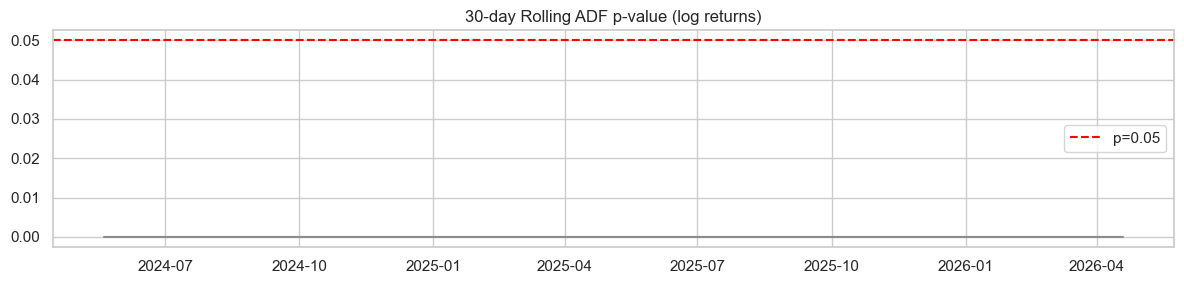

<details>
<summary>💡 Click to reveal solution</summary>

```python
win = 24 * 30  # 30 days of hours
step = 24      # advance one day at a time
r = btc['log_return'].dropna()
pvals, idxs = [], []
for end in range(win, len(r), step):
    seg = r.iloc[end - win:end]
    try:
        p = adfuller(seg, autolag='AIC')[1]
    except Exception:
        p = np.nan
    pvals.append(p); idxs.append(r.index[end - 1])
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(idxs, pvals, color='C7')
ax.axhline(0.05, color='red', ls='--', label='p=0.05')
ax.set_title('30-day Rolling ADF p-value (log returns)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Step the ADF over a sliding 720-hour window and stride by 24h to keep it cheap. Spikes above 0.05 flag periods when the series briefly looks non-stationary — usually transient and not a problem for return-based modelling.

</details>

**Exercise 4.2**: Run KPSS on price and log returns and **reconcile** with ADF. State the four ADF/KPSS combinations and what they imply.

In [21]:
# Your answer here


**Expected output:**

```text
[KPSS] close                 stat=+8.206  p=0.01  lags=77  -> non-stationary
[KPSS] log_return            stat=+0.201  p=0.1  lags=6  -> STATIONARY

ADF reject + KPSS not-reject => stationary
ADF not-reject + KPSS reject => non-stationary
Both reject              => trend-stationary or fractionally integrated
Neither rejects          => low power; need more data
```
```text
/tmp/ipykernel_733143/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
/tmp/ipykernel_733143/522047728.py:9: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, crit = kpss(s, regression="c", nlags="auto")
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
kpss_report(btc['close'], 'close')
kpss_report(btc['log_return'], 'log_return')
print()
print('ADF reject + KPSS not-reject => stationary')
print('ADF not-reject + KPSS reject => non-stationary')
print('Both reject              => trend-stationary or fractionally integrated')
print('Neither rejects          => low power; need more data')
```

**Explanation**: ADF and KPSS swap the null and alternative, so they can disagree. The four-way decision matrix is standard practice — agreement gives confidence; disagreement points at trend-stationarity, structural breaks, or insufficient data.

</details>

**Exercise 4.3**: First-difference price (`close.diff()`) and re-run ADF. Compare its p-value to ADF on `log_return`.

In [22]:
# Your answer here


**Expected output:**

```text
[ADF] diff(close)           stat=-30.203  p=0  lags=21  n=17496  -> STATIONARY
```
```text
[ADF] log_return            stat=-29.452  p=0  lags=22  n=17496  -> STATIONARY
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
diff_close = btc['close'].diff()
adf_report(diff_close, 'diff(close)')
adf_report(btc['log_return'], 'log_return')
```

**Explanation**: Both transforms remove the unit root, but log returns are scale-invariant — comparable across asset price levels — while raw differences are not. Use log returns for cross-asset modelling.

</details>

**Exercise 4.4**: Run ADF on `log(squared returns + eps)` and interpret. (This proxies log volatility — is it stationary?)

In [23]:
# Your answer here


**Expected output:**

```text
[ADF] log(returns^2)        stat=-15.228  p=5.376e-28  lags=28  n=17490  -> STATIONARY
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
eps = 1e-12
log_sq = np.log(btc['log_return'] ** 2 + eps)
adf_report(log_sq, 'log(returns^2)')
```

**Explanation**: Log squared returns is a noisy proxy for log realised variance. ADF typically rejects (stationary) but the series has long memory in practice — formal tests (Hurst, GPH) often suggest fractional integration. Either way, GARCH-style modelling is justified.

</details>

## 5. Seasonal Decomposition

Decompose price (or returns) into trend + seasonal + residual.

**Caveats**:
- Crypto trades 24/7 — seasonality is weak.
- `seasonal_decompose` uses centred moving averages; STL is more robust.
- We pick **additive** for log returns (the natural scale).

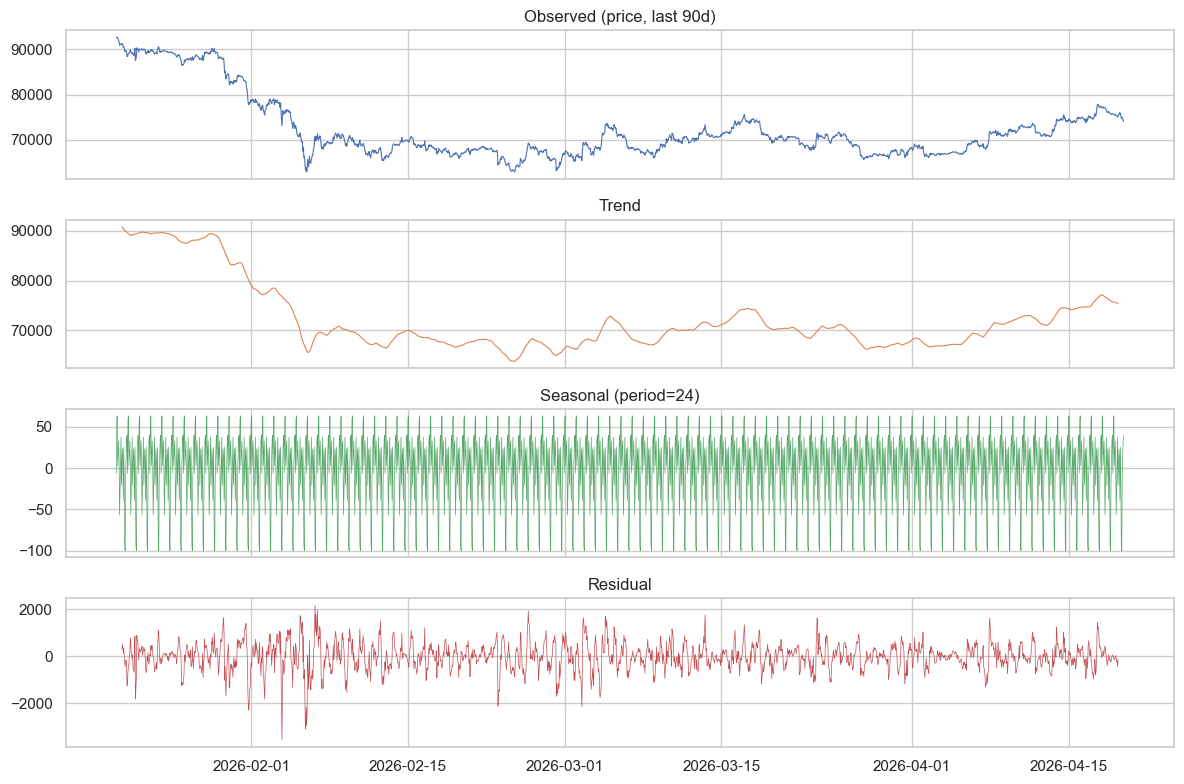

In [24]:
# Use last 90 days of price (additive decomposition with daily period=24)
window = btc.iloc[-24 * 90:]
decomp = seasonal_decompose(window["close"], model="additive", period=24)

fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)
axes[0].plot(window.index, decomp.observed, lw=0.8); axes[0].set_title("Observed (price, last 90d)")
axes[1].plot(window.index, decomp.trend, lw=0.8, color="C1"); axes[1].set_title("Trend")
axes[2].plot(window.index, decomp.seasonal, lw=0.5, color="C2"); axes[2].set_title("Seasonal (period=24)")
axes[3].plot(window.index, decomp.resid, lw=0.5, color="C3"); axes[3].set_title("Residual")
plt.tight_layout(); plt.show()

### Exercises — Decomposition

**Before you start — techniques you'll use:**

- **STL** (seasonal-trend-loess): `STL(series, period=24, robust=True).fit()` → has
  `.trend`, `.seasonal`, `.resid`. Plot the three on shared x-axes.
- **Classical decomposition**: `seasonal_decompose(series, model='additive',
  period=24)` — simpler, struggles with regime shifts.
- **Twin axis overlay**: `ax1.plot(price); ax2 = ax1.twinx(); ax2.plot(seasonal,
  color='C3')` to visualise a small seasonal pattern on top of a dominant trend.
- **Strength-of-seasonality**: $F_s = \max(0, 1 - \mathrm{Var}(R)/\mathrm{Var}(S+R))$.
  Close to 1 = strong seasonality; 0 = none.

*Mini-example (strength-of-seasonality):*
```python
S, R = decomp.seasonal.dropna(), decomp.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R[common].var() / (S[common] + R[common]).var())
```


**Worked example — STL and strength-of-seasonality**

A 24-period STL decomposition on a synthetic series with known intraday seasonality,
then computing the F_s strength metric to quantify how much of the variance is seasonal.


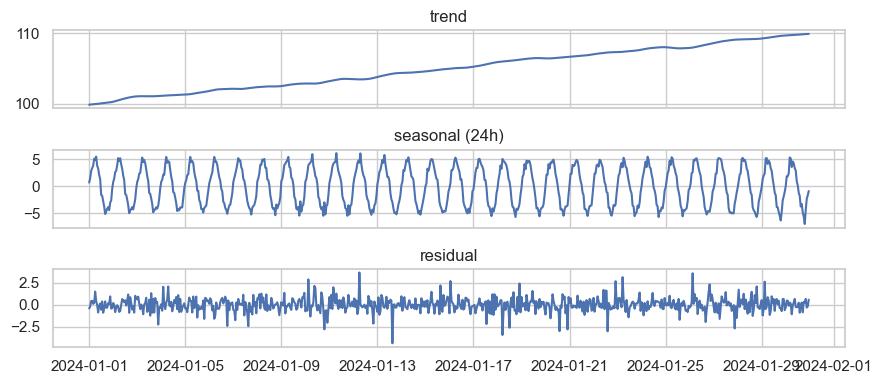

F_s strength of seasonality: 0.947   (1 = strong, 0 = none)
classical decomp seasonal std: 3.494
classical decomp residual std: 0.975


In [25]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import STL, seasonal_decompose

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*30, freq='1h', tz='UTC')
seasonal = 5 * np.sin(2 * np.pi * idx.hour / 24)
trend = np.linspace(100, 110, len(idx))
noise = rng.normal(0, 1, len(idx))
y = pd.Series(trend + seasonal + noise, index=idx)

# 1) STL with period=24.
stl = STL(y, period=24, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(9, 4), sharex=True)
axes[0].plot(stl.trend);    axes[0].set_title('trend')
axes[1].plot(stl.seasonal); axes[1].set_title('seasonal (24h)')
axes[2].plot(stl.resid);    axes[2].set_title('residual')
plt.tight_layout(); plt.show()

# 2) Strength-of-seasonality F_s.
S, R = stl.seasonal.dropna(), stl.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R[common].var() / (S[common] + R[common]).var())
print(f'F_s strength of seasonality: {Fs:.3f}   (1 = strong, 0 = none)')

# 3) Compare against classical decomposition (additive).
dec = seasonal_decompose(y, model='additive', period=24)
print(f'classical decomp seasonal std: {dec.seasonal.std():.3f}')
print(f'classical decomp residual std: {dec.resid.std():.3f}')


**Exercise 5.1**: Run **STL decomposition** with period=24 on the same 90-day window. Plot trend/seasonal/residual.

In [26]:
# Your answer here


**Expected output:**

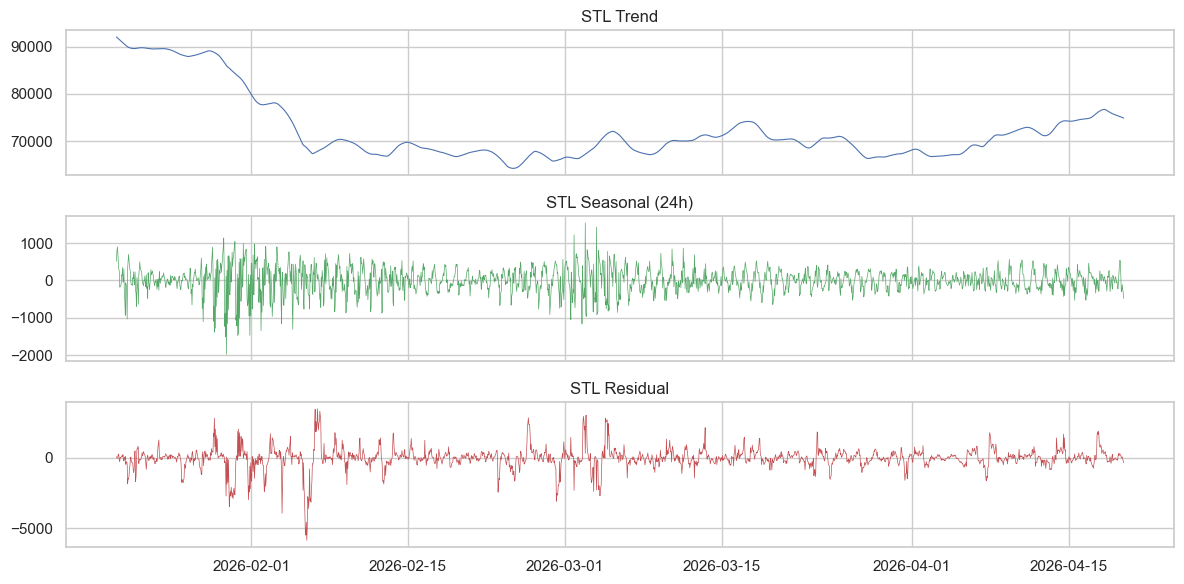

<details>
<summary>💡 Click to reveal solution</summary>

```python
stl = STL(window['close'], period=24, robust=True).fit()
fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
axes[0].plot(stl.trend, lw=0.8); axes[0].set_title('STL Trend')
axes[1].plot(stl.seasonal, lw=0.5, color='C2'); axes[1].set_title('STL Seasonal (24h)')
axes[2].plot(stl.resid, lw=0.5, color='C3'); axes[2].set_title('STL Residual')
plt.tight_layout(); plt.show()
```

**Explanation**: STL (Seasonal-Trend-LOESS) is more robust to outliers than `seasonal_decompose`. The `robust=True` flag downweights large residuals — important for crypto.

</details>

**Exercise 5.2**: Decompose **returns** (not price) with period=24 and interpret the seasonal magnitude vs the residual magnitude.

In [27]:
# Your answer here


**Expected output:**

```text
Seasonal std: 0.000607
Residual std: 0.005470
Seasonal / total: 10.802%
```
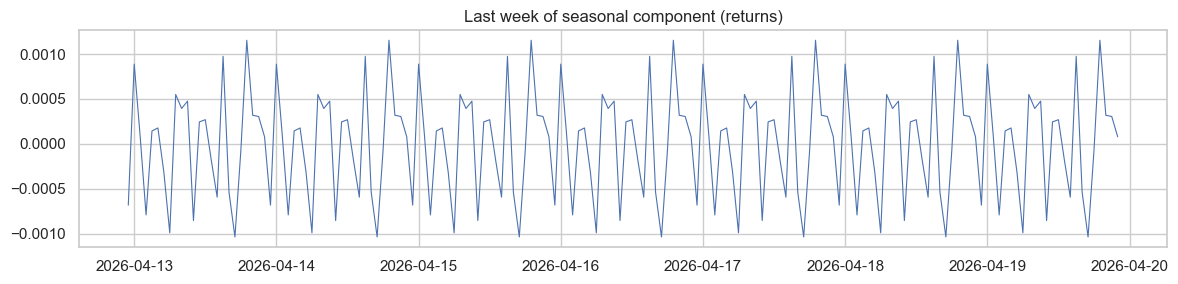

<details>
<summary>💡 Click to reveal solution</summary>

```python
win_r = btc['log_return'].iloc[-24 * 90:]
dec_r = seasonal_decompose(win_r, model='additive', period=24)
print(f'Seasonal std: {dec_r.seasonal.std():.6f}')
print(f'Residual std: {dec_r.resid.std():.6f}')
print(f'Seasonal / total: {dec_r.seasonal.std() / win_r.std():.3%}')
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(dec_r.seasonal[-24 * 7:], lw=0.8)
ax.set_title('Last week of seasonal component (returns)')
plt.tight_layout(); plt.show()
```

**Explanation**: Comparing seasonal std to residual std quantifies how much variance the diurnal cycle actually explains. For BTC returns this fraction is tiny (<5%) — seasonality is essentially noise at the hourly scale.

</details>

**Exercise 5.3**: Plot the **last 7 days** of the seasonal component overlaid on the raw price (twin axis).

In [28]:
# Your answer here


**Expected output:**

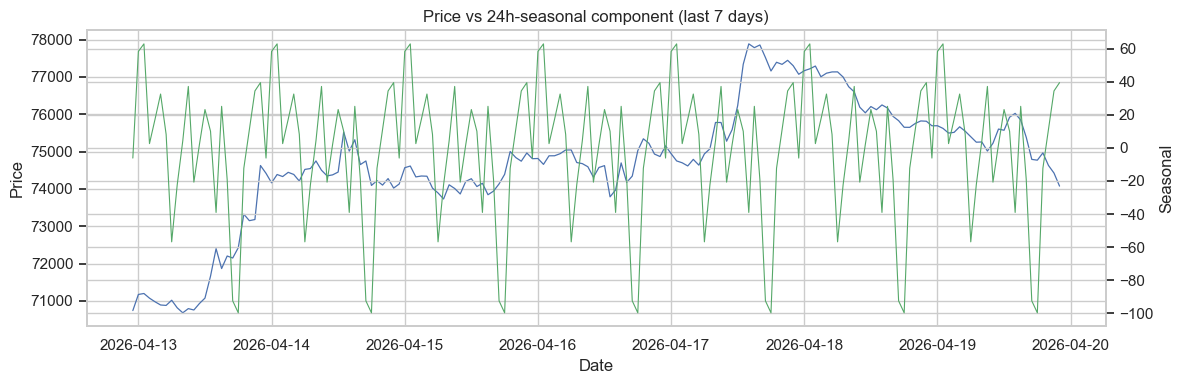

<details>
<summary>💡 Click to reveal solution</summary>

```python
last7 = decomp.seasonal[-24 * 7:]
raw7 = window['close'][-24 * 7:]
fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(raw7.index, raw7, color='C0', lw=0.9, label='Price')
ax1.set_ylabel('Price'); ax1.set_xlabel('Date')
ax2 = ax1.twinx()
ax2.plot(last7.index, last7, color='C2', lw=0.8, label='Seasonal')
ax2.set_ylabel('Seasonal')
ax1.set_title('Price vs 24h-seasonal component (last 7 days)')
plt.tight_layout(); plt.show()
```

**Explanation**: Overlay shows how visually-tiny the seasonal signal is relative to price moves. A useful sanity check that you're not chasing a periodic ghost.

</details>

**Exercise 5.4**: Compute a **strength-of-seasonality** metric: $F_s = \max(0, 1 - \mathrm{Var}(R)/\mathrm{Var}(S+R))$ where S, R are seasonal and residual components. Range [0, 1].

In [29]:
# Your answer here


**Expected output:**

```text
Strength of seasonality F_s = 0.005
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
S = decomp.seasonal.dropna()
R = decomp.resid.dropna()
common = S.index.intersection(R.index)
Fs = max(0.0, 1.0 - R.loc[common].var() / (S.loc[common] + R.loc[common]).var())
print(f'Strength of seasonality F_s = {Fs:.3f}')
```

**Explanation**: Hyndman's F_s metric (FPP3, ch.6.7). Values near 1 indicate strong seasonality; values near 0 mean the seasonal component adds essentially no explanatory power. Crypto hourly price hovers near zero.

</details>

## 6. Chronological Train/Test Split

**Last 30 days** = test, prior = train. Never shuffle time series — it leaks the future.

In [30]:
TEST_DAYS = 30
TEST_HOURS = 24 * TEST_DAYS

split_idx = len(btc) - TEST_HOURS
train = btc.iloc[:split_idx].copy()
test = btc.iloc[split_idx:].copy()
print(f"Train: {len(train)} hours ({train.index.min()} -> {train.index.max()})")
print(f"Test : {len(test)} hours ({test.index.min()} -> {test.index.max()})")
assert train.index.max() < test.index.min(), "Train and test must not overlap"


Train: 16799 hours (2024-04-20 00:00:00+00:00 -> 2026-03-20 22:00:00+00:00)
Test : 720 hours (2026-03-20 23:00:00+00:00 -> 2026-04-19 22:00:00+00:00)


### Exercises — Split

**Before you start — techniques you'll use:**

- **Walk-forward CV**: `TimeSeriesSplit(n_splits=5).split(train)` — expanding train,
  fixed-size val, chronological order preserved.
- **Distribution shift check**: `train['log_return'].agg(['mean', 'std', 'min',
  'max'])` vs same on test — big shifts predict worse test performance.
- **Disjointness + gap**: `train.index.intersection(test.index)` should be empty;
  `test.index.min() - train.index.max()` should be ≥ 1 bar.
- **Shuffled-split antipattern demo**: `rng.choice(n, TEST_HOURS, replace=False)`
  mixes eras — test mean/std match train mean/std, masking distribution shift.

*Mini-example (fold enumeration):*
```python
for i, (tr, va) in enumerate(TimeSeriesSplit(5).split(train)):
    print(f'Fold {i}: train={len(tr)}, val={len(va)}, val_start={train.index[va[0]]}')
```


**Worked example — chronological splits and TimeSeriesSplit**

A walk-forward CV on an expanding window using `TimeSeriesSplit`, an explicit
disjointness assertion, a check for distribution shift between train and test, and the
shuffled-split antipattern as a contrast.


In [31]:
import numpy as np, pandas as pd
from sklearn.model_selection import TimeSeriesSplit

rng = np.random.default_rng(0)
n = 500
y_train_dist = rng.normal(0, 1, int(n * 0.7))
y_test_dist  = rng.normal(0.5, 1, n - int(n * 0.7))   # distribution shift!
y = pd.Series(np.r_[y_train_dist, y_test_dist])

# 1) TimeSeriesSplit folds.
tscv = TimeSeriesSplit(n_splits=4)
print('TimeSeriesSplit folds:')
for i, (tr, va) in enumerate(tscv.split(y)):
    print(f'  fold {i}: train [0..{tr[-1]}]  val [{va[0]}..{va[-1]}]')

# 2) Train/test temporal disjointness assertion.
cut = int(n * 0.7)
train, test = y.index[:cut], y.index[cut:]
assert train.max() < test.min(), 'temporal overlap!'
print('\ntrain/test disjoint OK')

# 3) Distribution-shift check between train and test.
print('\ntrain/test summary:')
print(pd.DataFrame({'train': y[train].agg(['mean', 'std']),
                    'test':  y[test].agg(['mean', 'std'])}).round(3))

# 4) Shuffled-split antipattern: train sees rows from the post-shift era.
shuf_test = rng.choice(n, size=len(test), replace=False)
shuf_train = np.setdiff1d(np.arange(n), shuf_test)
print(f'\nshuffled split mean(train) = {y.iloc[shuf_train].mean():+.3f}, '
      f'mean(test) = {y.iloc[shuf_test].mean():+.3f}  ← shift hidden')
print(f'chronological mean(train) = {y[train].mean():+.3f}, '
      f'mean(test) = {y[test].mean():+.3f}  ← shift visible')


TimeSeriesSplit folds:
  fold 0: train [0..99]  val [100..199]
  fold 1: train [0..199]  val [200..299]
  fold 2: train [0..299]  val [300..399]
  fold 3: train [0..399]  val [400..499]

train/test disjoint OK

train/test summary:
      train   test
mean -0.040  0.503
std   1.008  1.034

shuffled split mean(train) = +0.145, mean(test) = +0.071  ← shift hidden
chronological mean(train) = -0.040, mean(test) = +0.503  ← shift visible


**Exercise 6.1**: Implement a **walk-forward CV** with 5 expanding-window folds on `train` (using `sklearn.model_selection.TimeSeriesSplit`). Print fold sizes.

In [32]:
# Your answer here


**Expected output:**

```text
Fold 0: train=  2804  val= 2799  val_start=2024-08-14 20:00:00+00:00
Fold 1: train=  5603  val= 2799  val_start=2024-12-09 11:00:00+00:00
Fold 2: train=  8402  val= 2799  val_start=2025-04-05 02:00:00+00:00
Fold 3: train= 11201  val= 2799  val_start=2025-07-30 17:00:00+00:00
Fold 4: train= 14000  val= 2799  val_start=2025-11-24 08:00:00+00:00
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
tscv = TimeSeriesSplit(n_splits=5)
for i, (tr_idx, va_idx) in enumerate(tscv.split(train)):
    print(f'Fold {i}: train={len(tr_idx):>6d}  val={len(va_idx):>5d}  '
          f'val_start={train.index[va_idx[0]]}')
```

**Explanation**: `TimeSeriesSplit` produces expanding-window folds where each train set is a prefix of the data. This mirrors how the model is actually used in production — fit on the past, score on the future.

</details>

**Exercise 6.2**: Compare **mean and std** of `log_return` between train and test. Big shifts hint at distribution drift.

In [33]:
# Your answer here


**Expected output:**

```text
         train      test
mean  0.000006  0.000063
std   0.005083  0.004394
min  -0.050195 -0.019849
max   0.049047  0.022660
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
summary = pd.DataFrame({
    'train': train['log_return'].agg(['mean', 'std', 'min', 'max']),
    'test':  test['log_return'].agg(['mean', 'std', 'min', 'max']),
})
print(summary)
```

**Explanation**: Compare moments to spot regime changes. Big mean/std shifts mean your IS metrics overstate OOS performance — common in crypto where vol regimes flip quickly.

</details>

**Exercise 6.3**: **Verify no overlap**: assert `train.index` and `test.index` are disjoint, and that train ends exactly one hour before test starts.

In [34]:
# Your answer here


**Expected output:**

```text
Train ends: 2026-03-20 22:00:00+00:00
Test starts: 2026-03-20 23:00:00+00:00
Gap: 0 days 01:00:00  (expect 1 hour)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
overlap = train.index.intersection(test.index)
assert len(overlap) == 0, f'Overlap of {len(overlap)} timestamps!'
gap = test.index.min() - train.index.max()
print(f'Train ends: {train.index.max()}')
print(f'Test starts: {test.index.min()}')
print(f'Gap: {gap}  (expect 1 hour)')
assert gap == pd.Timedelta('1h'), 'Train/test should be exactly 1h apart'
```

**Explanation**: Three asserts: empty intersection, exact 1-hour gap. Catching a 1-row off-by-one here saves hours of confused debugging later.

</details>

**Exercise 6.4**: Show with a tiny code snippet **why** a shuffled split breaks the problem (compute test-set mean if you randomly sample test indices from anywhere in the series; show how naive baselines fitted on train look).

In [35]:
# Your answer here


**Expected output:**

```text
Chronological test mean : 6.344525252817886e-05
Shuffled     test mean  : -0.000230445389499101
Shuffled train contains hours AFTER shuffled test?  True
=> shuffled split lets the model peek at the future via lag features
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
shuf_test_idx = rng.choice(len(btc), size=TEST_HOURS, replace=False)
shuf_train_idx = np.setdiff1d(np.arange(len(btc)), shuf_test_idx)
print('Chronological test mean :', test['log_return'].mean())
print('Shuffled     test mean  :', btc['log_return'].iloc[shuf_test_idx].mean())
print('Shuffled train contains hours AFTER shuffled test? ',
      btc.index[shuf_train_idx].max() > btc.index[shuf_test_idx].min())
print('=> shuffled split lets the model peek at the future via lag features')
```

**Explanation**: Shuffled splits put future bars in train and past bars in test — every lag feature becomes a leak. The print statement makes the temporal contamination obvious.

</details>

## 7. Naive Baselines

For 1-step-ahead return forecasting:
- **Zero-return** (efficient market hypothesis): $\hat r_t = 0$.
- **Random-walk on price**: $\hat p_t = p_{t-1}$ → equivalent to predicting $\hat r_t = 0$.
- **Seasonal naive (daily)**: $\hat r_t = r_{t-24}$.
- **Seasonal naive (weekly)**: $\hat r_t = r_{t-168}$.

In [36]:
def metrics(y_true, y_pred, name):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    yt, yp = y_true[mask], y_pred[mask]
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae = mean_absolute_error(yt, yp)
    # directional accuracy: ignore exact zeros
    nz = (yt != 0)
    dir_acc = (np.sign(yp[nz]) == np.sign(yt[nz])).mean()
    return {"model": name, "rmse": rmse, "mae": mae, "dir_acc": dir_acc, "n": int(mask.sum())}

y_test = test["log_return"].values

# Naive: predict zero
pred_zero = np.zeros_like(y_test)

# Seasonal naive: predict r_{t-24} (daily)
last_train_returns = btc["log_return"].copy()
pred_sn24 = last_train_returns.shift(24).loc[test.index].values

# Seasonal naive: predict r_{t-168} (weekly)
pred_sn168 = last_train_returns.shift(168).loc[test.index].values

baseline_results = [
    metrics(y_test, pred_zero, "naive_zero"),
    metrics(y_test, pred_sn24, "seasonal_naive_24h"),
    metrics(y_test, pred_sn168, "seasonal_naive_168h"),
]
pd.DataFrame(baseline_results).round(6)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Exercises — Naive Baselines

**Before you start — techniques you'll use:**

- **Seasonal naive**: predict y at time t = y at time `t - period`. For hourly data
  and a weekly cycle, period = 168. Handle missing lookups with `get(ts, np.nan)`.
- **Blending baselines**: `0.5 * pred_a + 0.5 * np.nan_to_num(pred_b, 0)` — nan-safe
  combination keeps one model from dropping its turn.
- **Directional accuracy (manual)**: `mask = ~np.isnan(p) & (y != 0)`, then
  `(np.sign(p[mask]) == np.sign(y[mask])).mean()`.
- **Bootstrap RMSE CI**: resample residuals (not the raw series — residuals are
  roughly iid after demeaning), recompute RMSE, take 2.5 / 97.5 percentiles.

*Mini-example (seasonal-naive manual):*
```python
preds = [btc['log_return'].get(ts - pd.Timedelta(hours=168), np.nan) for ts in test.index]
```


**Worked example — seasonal naive, blending, directional accuracy, bootstrap**

Each exercise asks you to implement a different baseline-flavoured idiom; this cell
walks through all four on a tiny series so you can see the moving parts.


In [37]:
import numpy as np, pandas as pd
import math

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*14, freq='1h', tz='UTC')
y = pd.Series(rng.normal(0, 0.01, len(idx)), index=idx)
test_idx = idx[-24:]; y_test = y.loc[test_idx].values

# 1) Seasonal naive at period=24 (manual lookup).
def seasonal_naive(history, target_idx, period):
    return np.array([history.get(t - pd.Timedelta(hours=period), np.nan) for t in target_idx])

pred_sn24 = seasonal_naive(y, test_idx, 24)
print(f'seasonal-naive 24h: {pred_sn24[:3].round(5)} ...')

# 2) Blend two baselines, nan-safe.
pred_zero = np.zeros_like(y_test)
blend = 0.5 * pred_zero + 0.5 * np.nan_to_num(pred_sn24, nan=0.0)
print(f'blend mean abs error: {np.mean(np.abs(y_test - blend)):.5f}')

# 3) Directional accuracy (manual).
mask = ~np.isnan(pred_sn24) & (y_test != 0)
hit = (np.sign(pred_sn24[mask]) == np.sign(y_test[mask])).mean()
print(f'directional acc on seasonal-naive: {hit:.3f}')

# 4) Bootstrap 95% CI on naive-zero RMSE.
resid = y_test - pred_zero
boot = []
for _ in range(500):
    idx_b = rng.integers(0, len(resid), len(resid))
    boot.append(math.sqrt(np.mean(resid[idx_b] ** 2)))
print(f'naive-zero RMSE 95% CI: [{np.quantile(boot, 0.025):.5f}, {np.quantile(boot, 0.975):.5f}]')


seasonal-naive 24h: [-0.0064   0.00732 -0.01171] ...
blend mean abs error: 0.00664
directional acc on seasonal-naive: 0.500
naive-zero RMSE 95% CI: [0.00549, 0.00862]


**Exercise 7.1**: Implement seasonal naive at period=168 (weekly) **manually** (no shift): for each test timestamp t, look up `log_return` 168 hours before t.

In [38]:
# Your answer here


**Expected output:**

```text
{'model': 'manual_sn168', 'rmse': np.float64(0.006242775707519551), 'mae': 0.00437709493945163, 'dir_acc': np.float64(0.5069444444444444), 'n': 720}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
preds = []
for ts in test.index:
    src = ts - pd.Timedelta(hours=168)
    preds.append(btc['log_return'].get(src, np.nan))
preds = np.array(preds)
print(metrics(y_test, preds, 'manual_sn168'))
```

**Explanation**: Manual lookup verifies the `shift(168)` approach gives identical results. Useful when you want custom calendar-aware lookups (e.g. skip weekends for traditional markets).

</details>

**Exercise 7.2**: **Blend** naive (predict 0) with seasonal naive 24h, 50/50. Compare metrics.

In [39]:
# Your answer here


**Expected output:**

```text
{'model': 'blend_zero_sn24', 'rmse': np.float64(0.0049824751751698605), 'mae': 0.003480639750177106, 'dir_acc': np.float64(0.5166666666666667), 'n': 720}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
blend = 0.5 * pred_zero + 0.5 * np.nan_to_num(pred_sn24, nan=0.0)
print(metrics(y_test, blend, 'blend_zero_sn24'))
```

**Explanation**: Blending shrinks the seasonal-naive prediction toward zero. For a near-random-walk series this typically improves RMSE simply because shrinking variance reduces MSE.

</details>

**Exercise 7.3**: Compute **directional accuracy manually** for `pred_sn24` without using the helper: count of `sign(pred) == sign(actual)` where actual != 0, divided by N.

In [40]:
# Your answer here


**Expected output:**

```text
manual dir_acc = 0.5167  (372/720)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
p = pred_sn24
y = y_test
mask = ~np.isnan(p) & (y != 0)
hit = (np.sign(p[mask]) == np.sign(y[mask])).sum()
n = mask.sum()
print(f'manual dir_acc = {hit / n:.4f}  ({hit}/{n})')
```

**Explanation**: Direct check that the helper isn't doing anything sneaky. Always sanity-check key metrics by hand at least once.

</details>

**Exercise 7.4**: Compute a **bootstrap 95% CI** on the naive-zero RMSE (1000 resamples of the test residuals).

In [41]:
# Your answer here


**Expected output:**

```text
naive-zero RMSE 95% CI: [0.003997, 0.004783]
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
resid = y_test - pred_zero
boot_rmse = []
for _ in range(1000):
    idx = rng.integers(0, len(resid), size=len(resid))
    boot_rmse.append(np.sqrt(np.mean(resid[idx] ** 2)))
lo, hi = np.percentile(boot_rmse, [2.5, 97.5])
print(f'naive-zero RMSE 95% CI: [{lo:.6f}, {hi:.6f}]')
```

**Explanation**: A bootstrap CI tells you the noise in your point estimate. If a competing model's RMSE falls inside this CI, the improvement isn't statistically meaningful.

</details>

## 8. Classical: ETS (Exponential Smoothing)

We fit **simple exponential smoothing (SES) on log returns** — appropriate when there is no clear trend or seasonality (which is the case for hourly returns).

For each test step, we re-fit SES on the expanding training window and predict 1 step. To keep this fast we update by **appending the new observation to the model** rather than refitting from scratch.

In [42]:
# Walk-forward 1-step-ahead with SES on log returns.
# Trick: refit only every K steps to keep runtime manageable.
REFIT_EVERY = 24  # refit once per day

train_ret = train["log_return"].copy()
preds_ets = []
fitted_model = None

t0 = time.time()
for i, ts in enumerate(test.index):
    history = pd.concat([train_ret, test["log_return"].iloc[:i]])
    if i % REFIT_EVERY == 0 or fitted_model is None:
        fitted_model = ExponentialSmoothing(
            history.values, trend=None, seasonal=None, initialization_method="estimated"
        ).fit(optimized=True)
    yhat = fitted_model.forecast(1)[0]
    preds_ets.append(yhat)
preds_ets = np.array(preds_ets)
print(f"ETS walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_ets, "ets_ses"))


IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

### Exercises — ETS

**Before you start — techniques you'll use:**

- **Holt-Winters**: `ExponentialSmoothing(series, trend='add', seasonal='add',
  seasonal_periods=24).fit()` — captures level, slope, and 24h seasonality.
- **Damped trend** (for forecasts that shouldn't explode):
  `trend='add', damped_trend=True`. Compare AIC vs the undamped fit.
- **Smoothing parameter**: `fit.params['smoothing_level']` is α. α ≈ 0 → heavy
  smoothing (forecast = long mean); α ≈ 1 → no smoothing (forecast = last value).
- **In-sample fit check**: `model.fittedvalues` — plot over actual; used to sanity-
  check that the fit didn't collapse to the mean.

*Mini-example (HW on last 14 days):*
```python
hist, future = btc['close'].iloc[-24*14:-24], btc['close'].iloc[-24:]
hw = ExponentialSmoothing(hist, trend='add', seasonal='add', seasonal_periods=24).fit()
pred = hw.forecast(24)
```


**Worked example — ExponentialSmoothing in 4 modes**

Holt-Winters with seasonality, a damped-trend ETS, the smoothing-alpha parameter, and
the in-sample fitted values plot. Each exercise picks one of these threads to extend.


HW forecast MAE on next 24h: 0.401
damped trend AIC: -409.4
undamped     AIC: -348.9

SES alpha: 0.865


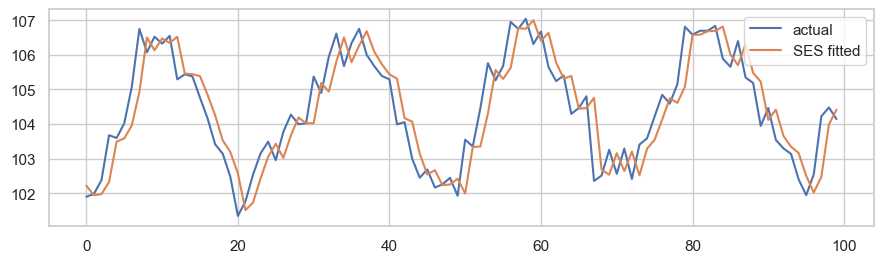

In [43]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*30, freq='1h', tz='UTC')
trend = np.linspace(100, 105, len(idx))
seasonal = 2 * np.sin(2 * np.pi * idx.hour / 24)
noise = rng.normal(0, 0.5, len(idx))
y = pd.Series(trend + seasonal + noise, index=idx)
hist, true_next = y.iloc[:-24], y.iloc[-24:]

# 1) Holt-Winters with seasonal_periods=24.
hw = ExponentialSmoothing(hist, trend='add', seasonal='add', seasonal_periods=24).fit()
fc = hw.forecast(24)
print(f'HW forecast MAE on next 24h: {np.mean(np.abs(true_next.values - fc.values)):.3f}')

# 2) Damped trend.
damped = ExponentialSmoothing(hist, trend='add', damped_trend=True,
                               initialization_method='estimated').fit()
print(f'damped trend AIC: {damped.aic:.1f}')
print(f'undamped     AIC: {ExponentialSmoothing(hist, trend="add", initialization_method="estimated").fit().aic:.1f}')

# 3) Smoothing alpha — α≈1 = trust last observation only; α≈0 = heavy smoothing.
ses = ExponentialSmoothing(hist, trend=None, initialization_method='estimated').fit()
print(f'\nSES alpha: {ses.params["smoothing_level"]:.3f}')

# 4) In-sample fit on the last 100 hours.
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(hist.iloc[-100:].values, label='actual')
ax.plot(ses.fittedvalues[-100:].values, label='SES fitted')
ax.legend(); plt.tight_layout(); plt.show()


**Exercise 8.1**: Fit a **Holt-Winters** model with `seasonal_periods=24` on the **last 14 days of price** (additive), forecast 24 hours ahead, plot.

In [44]:
# Your answer here


**Expected output:**

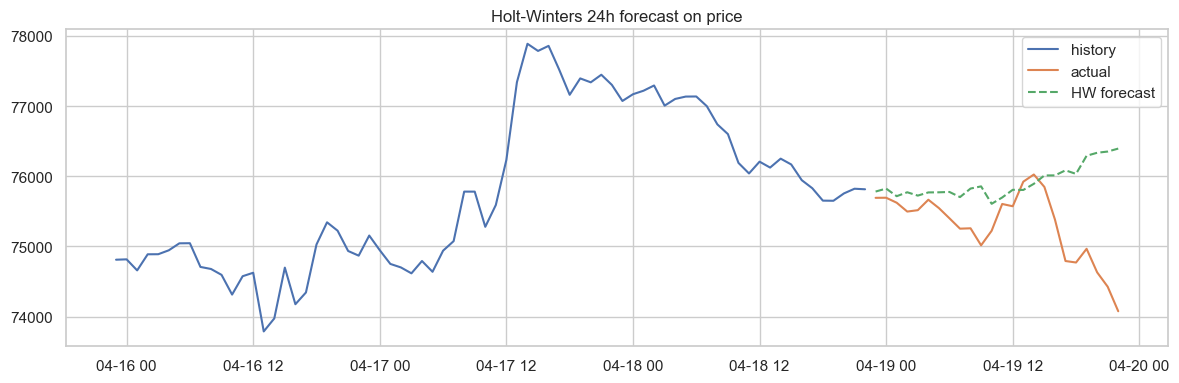

<details>
<summary>💡 Click to reveal solution</summary>

```python
hist = btc['close'].iloc[-24 * 14:-24]
actual_next = btc['close'].iloc[-24:]
hw = ExponentialSmoothing(hist, trend='add', seasonal='add',
                          seasonal_periods=24,
                          initialization_method='estimated').fit()
fc = hw.forecast(24)
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(hist.index[-24 * 3:], hist.iloc[-24 * 3:], label='history')
ax.plot(actual_next.index, actual_next.values, label='actual')
ax.plot(actual_next.index, fc.values, label='HW forecast', ls='--')
ax.set_title('Holt-Winters 24h forecast on price')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Holt-Winters adds a seasonal component to ETS. On price (non-stationary) it tends to over-fit short trends and seasonal cycles in crypto, but the visualisation makes the dangers clear.

</details>

**Exercise 8.2**: Fit ETS with **damped trend** on log returns and compare AIC against the SES model.

In [45]:
# Your answer here


**Expected output:**

```text
SES AIC          : -177459.97
Damped trend AIC : -177454.08
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
m1 = ExponentialSmoothing(train_ret.values, trend=None,
                          initialization_method='estimated').fit()
m2 = ExponentialSmoothing(train_ret.values, trend='add', damped_trend=True,
                          initialization_method='estimated').fit()
print(f'SES AIC          : {m1.aic:.2f}')
print(f'Damped trend AIC : {m2.aic:.2f}')
```

**Explanation**: Damped trend (Gardner-McKenzie) shrinks the slope toward zero with phi<1. For pure-noise return series, trend models tend to overfit and have higher AIC. Lower AIC is better.

</details>

**Exercise 8.3**: Show the **learned smoothing parameter alpha** for the last fitted SES model.

In [46]:
# Your answer here


**Expected output:**

```text
Learned alpha: 0.0000
alpha ~ 0   => heavy smoothing (forecast = long mean)
alpha ~ 1   => no smoothing (forecast = last observation)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
alpha = fitted_model.params['smoothing_level']
print(f'Learned alpha: {alpha:.4f}')
print('alpha ~ 0   => heavy smoothing (forecast = long mean)')
print('alpha ~ 1   => no smoothing (forecast = last observation)')
```

**Explanation**: alpha is fit by maximum likelihood. For near-zero-mean noise the optimiser usually drives alpha toward 0, meaning SES reduces to forecasting the long-run mean (~0).

</details>

**Exercise 8.4**: Plot **in-sample fitted vs actual** for the SES on the **last 200 hours** of train.

In [47]:
# Your answer here


**Expected output:**

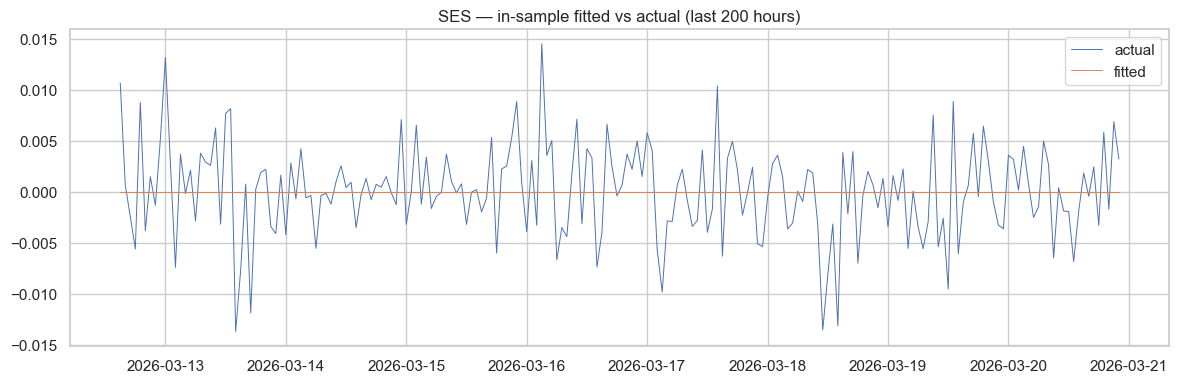

<details>
<summary>💡 Click to reveal solution</summary>

```python
model = ExponentialSmoothing(train_ret.values, trend=None,
                             initialization_method='estimated').fit()
fitted = model.fittedvalues
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(train_ret.index[-200:], train_ret.values[-200:], label='actual', lw=0.7)
ax.plot(train_ret.index[-200:], fitted[-200:], label='fitted', lw=0.7)
ax.set_title('SES — in-sample fitted vs actual (last 200 hours)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: On near-noise series the SES fitted line collapses to a near-flat track close to zero. This visually confirms why ETS rarely beats naive on hourly crypto returns.

</details>

## 9. Classical: SARIMA (small grid)

We fit SARIMA on log returns (already differenced once via the log-return transform, so d=0). Tiny grid:
- $(p,d,q) \in \{0,1,2\} \times \{0\} \times \{0,1,2\}$
- $(P,D,Q,s) = (P,0,Q,24)$ with $P, Q \in \{0,1\}$

Pick best by AIC on a **subsample** of train (last 6000 hours) — full history would be slow.

**Walk-forward**: refit every 24h to keep it CPU-friendly.

In [48]:
TRAIN_SUBSAMPLE = 6000  # last N hours of train for grid search
sub = train["log_return"].iloc[-TRAIN_SUBSAMPLE:]

best_aic = np.inf
best_order = None
best_seasonal = None

t0 = time.time()
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(sub, order=(p, 0, q), seasonal_order=(P, 0, Q, 24),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
                    if m.aic < best_aic:
                        best_aic = m.aic
                        best_order = (p, 0, q)
                        best_seasonal = (P, 0, Q, 24)
                except Exception:
                    continue
print(f"SARIMA grid took {time.time() - t0:.1f}s")
print(f"Best SARIMA{best_order}x{best_seasonal}  AIC={best_aic:.2f}")

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [49]:
# Walk-forward 1-step-ahead with the chosen order
t0 = time.time()
preds_sarima = []
fitted_sarima = None
REFIT_EVERY_S = 48  # refit every 2 days

for i, ts in enumerate(test.index):
    history = pd.concat([train["log_return"], test["log_return"].iloc[:i]])
    if i % REFIT_EVERY_S == 0 or fitted_sarima is None:
        # use only last 4000 hours for refit speed
        hist_used = history.iloc[-4000:]
        fitted_sarima = SARIMAX(hist_used.values, order=best_order,
                                seasonal_order=best_seasonal,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
    yhat = fitted_sarima.forecast(1)[0]
    preds_sarima.append(yhat)

preds_sarima = np.array(preds_sarima)
print(f"SARIMA walk-forward took {time.time() - t0:.1f}s")
print(metrics(y_test, preds_sarima, f'sarima{best_order}x{best_seasonal}'))

AttributeError: 'RangeIndex' object has no attribute 'index'

### Exercises — SARIMA

**Before you start — techniques you'll use:**

- **Residual diagnostics**: `plot_acf(resid, lags=48)` and
  `acorr_ljungbox(resid, lags=[24], return_df=True)`. p > 0.05 means residuals look
  like white noise — what you want.
- **Small grid search**: loop `(p, q, P, Q)` in small ranges, fit with
  `SARIMAX(...).fit(disp=False)`, collect `(params, aic)` rows, sort by AIC.
- **AR(1) by hand**: stack `X = [1, y_{t-1}]`, solve `beta = np.linalg.lstsq(X, y,
  rcond=None)[0]`. Compare `phi` to `SARIMAX(order=(1,0,0))` output.
- **In-sample fitted**: `fitted_sarima.fittedvalues[-200:]` vs actual —
  tight overlap on returns is suspicious (means model is trading the noise).

*Mini-example (manual AR(1)):*
```python
y = r[1:]; X = np.column_stack([np.ones_like(r[:-1]), r[:-1]])
c, phi = np.linalg.lstsq(X, y, rcond=None)[0]
```


**Worked example — SARIMA, residual diagnostics, manual AR(1)**

A small SARIMAX fit, the standard residual ACF + Ljung-Box pair, and a manual AR(1)
fit via OLS. The exercises generalise each of these.


SARIMA AR(1) coef: 0.991    AIC: 1135.7


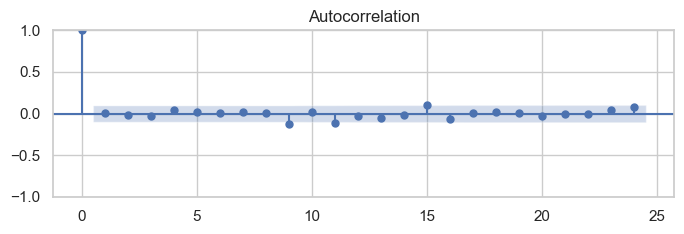


Ljung-Box (lag 12):
    lb_stat  lb_pvalue
12  13.6769     0.3218
manual AR(1) intercept=-0.038  phi=0.390  (target 0.4)


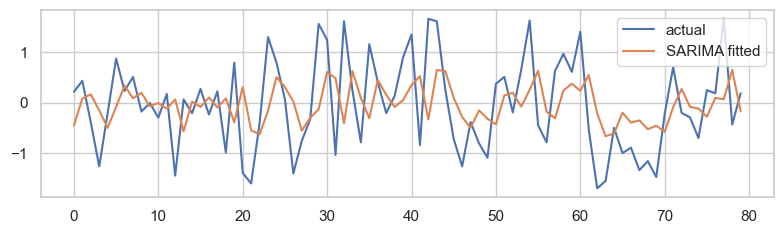

In [50]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(0)
n = 400
phi = 0.4
y = np.zeros(n)
for t in range(1, n):
    y[t] = phi * y[t-1] + rng.normal(0, 1)
y = pd.Series(y)

# 1) SARIMA(1,0,0) fit.
m = SARIMAX(y, order=(1, 0, 0)).fit(disp=False)
print(f'SARIMA AR(1) coef: {m.params[1]:.3f}    AIC: {m.aic:.1f}')

# 2) Residual ACF + Ljung-Box.
resid = pd.Series(m.resid).dropna()
fig, ax = plt.subplots(figsize=(7, 2.5))
plot_acf(resid, lags=24, ax=ax); plt.tight_layout(); plt.show()
print('\nLjung-Box (lag 12):'); print(acorr_ljungbox(resid, lags=[12], return_df=True).round(4))

# 3) Manual AR(1) via OLS — should match SARIMA's coef closely.
y_lag = y.shift(1).dropna(); y_now = y.iloc[1:]
X = np.column_stack([np.ones(len(y_lag)), y_lag.values])
beta, *_ = np.linalg.lstsq(X, y_now.values, rcond=None)
print(f'manual AR(1) intercept={beta[0]:.3f}  phi={beta[1]:.3f}  (target {phi})')

# 4) In-sample fitted values vs actuals on last 80 obs.
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(y.iloc[-80:].values, label='actual')
ax.plot(m.fittedvalues[-80:].values, label='SARIMA fitted')
ax.legend(); plt.tight_layout(); plt.show()


**Exercise 9.1**: Plot the **residual ACF** of the best SARIMA fit and run a **Ljung-Box test** at lag 24. Are residuals white noise?

In [51]:
# Your answer here


**Expected output:**

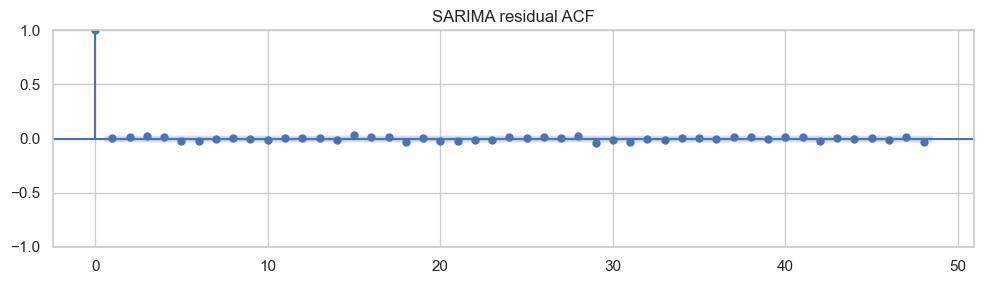
```text
      lb_stat  lb_pvalue
24  25.833436    0.36167
p > 0.05 => residuals indistinguishable from white noise
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
resid = pd.Series(fitted_sarima.resid).dropna()
fig, ax = plt.subplots(figsize=(10, 3))
plot_acf(resid, lags=48, ax=ax)
ax.set_title('SARIMA residual ACF')
plt.tight_layout(); plt.show()
lb = acorr_ljungbox(resid, lags=[24], return_df=True)
print(lb)
print('p > 0.05 => residuals indistinguishable from white noise')
```

**Explanation**: Residual ACF should be flat. Ljung-Box at lag 24 tests autocorrelation up to 1 day — large p-value means no remaining structure for the model to exploit.

</details>

**Exercise 9.2**: Re-run the grid and print the **top 3 by AIC**. Compare ΔAIC.

In [52]:
# Your answer here


**Expected output:**

```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
```
```text
       order       seasonal           aic  delta_aic
0  (0, 0, 0)  (0, 0, 0, 24) -47261.484035   0.000000
1  (1, 0, 0)  (0, 0, 0, 24) -47259.778539   1.705496
2  (0, 0, 1)  (0, 0, 0, 24) -47250.898085  10.585950
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
results = []
for p in [0, 1, 2]:
    for q in [0, 1, 2]:
        for P in [0, 1]:
            for Q in [0, 1]:
                try:
                    m = SARIMAX(sub, order=(p, 0, q), seasonal_order=(P, 0, Q, 24),
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(disp=False, maxiter=50)
                    results.append({'order': (p, 0, q),
                                    'seasonal': (P, 0, Q, 24), 'aic': m.aic})
                except Exception:
                    pass
df = pd.DataFrame(results).sort_values('aic').head(3).reset_index(drop=True)
df['delta_aic'] = df['aic'] - df['aic'].iloc[0]
print(df)
```

**Explanation**: Reporting the top-K is honest: if delta-AIC < 2 the models are essentially indistinguishable. Always treat AIC ranking as ordinal, not absolute.

</details>

**Exercise 9.3**: Implement an **AR(1) by hand** on `train_ret`: $r_t = c + \phi r_{t-1} + \epsilon_t$ via OLS. Verify $\phi$ matches statsmodels' SARIMAX(1,0,0).

In [53]:
# Your answer here


**Expected output:**

```text
manual c=+0.000007  phi=-0.016236
```
```text
sm     c=+0.000007  phi=-0.016236
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
r = train_ret.dropna().values
y = r[1:]
X = np.column_stack([np.ones_like(r[:-1]), r[:-1]])
beta, *_ = np.linalg.lstsq(X, y, rcond=None)
c_hat, phi_hat = beta
print(f'manual c={c_hat:+.6f}  phi={phi_hat:+.6f}')
sm = SARIMAX(r, order=(1, 0, 0), trend='c').fit(disp=False)
print(f'sm     c={sm.params[0]:+.6f}  phi={sm.params[1]:+.6f}')
```

**Explanation**: AR(1) is just OLS of r_t on r_{t-1}. Both methods should agree to 4+ decimals — useful as a sanity check that you understand what statsmodels is doing under the hood.

</details>

**Exercise 9.4**: Plot **in-sample fitted vs actual residuals** of the last SARIMA fit on the last 200 observations.

In [54]:
# Your answer here


**Expected output:**

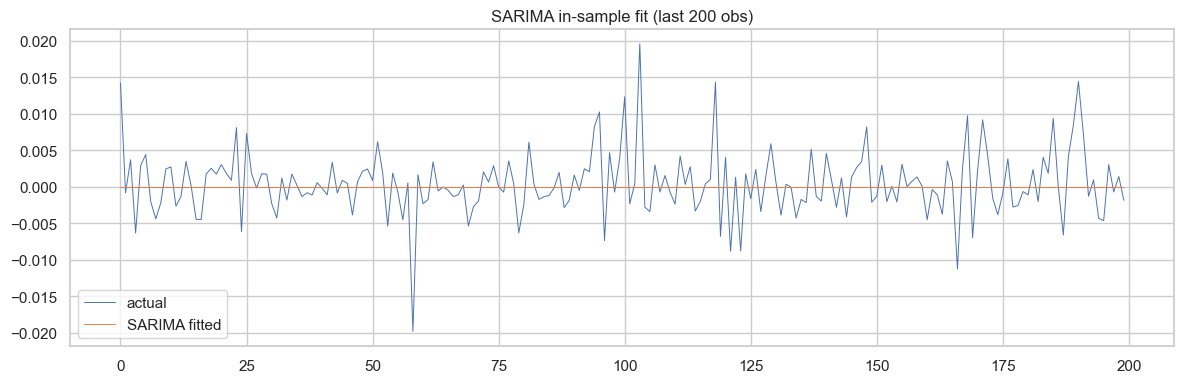

<details>
<summary>💡 Click to reveal solution</summary>

```python
fitted_vals = fitted_sarima.fittedvalues[-200:]
actual_vals = pd.Series(fitted_sarima.data.endog).iloc[-200:].values
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(actual_vals, label='actual', lw=0.7)
ax.plot(fitted_vals, label='SARIMA fitted', lw=0.7)
ax.set_title('SARIMA in-sample fit (last 200 obs)')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: If fitted essentially overlays actual the model is overfit. For near-noise data fitted should hug zero — anything else suggests parameter capture of noise.

</details>

## 10. Lag-Feature Engineering for ML

We turn the time series into a tabular regression problem. Features at time $t$ use **only data observed up to $t$** (no leakage):
- Lags of `log_return`: 1, 2, 3, 6, 12, 24, 48, 168
- Rolling mean and std of `log_return` over 24h, 168h
- Rolling vol of squared returns
- Calendar: hour-of-day, day-of-week (sin/cos encoded)
- Volume z-score (rolling 168h)

In [55]:
LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
ROLL_WINDOWS = [24, 168]

def make_features(df):
    out = pd.DataFrame(index=df.index)
    r = df["log_return"]
    for l in LAGS:
        out[f"lag_{l}"] = r.shift(l)
    for w in ROLL_WINDOWS:
        out[f"rmean_{w}"] = r.shift(1).rolling(w).mean()
        out[f"rstd_{w}"]  = r.shift(1).rolling(w).std()
        out[f"rvol2_{w}"] = (r.shift(1) ** 2).rolling(w).mean()
    # Calendar
    h = df.index.hour
    d = df.index.dayofweek
    out["sin_h"] = np.sin(2 * np.pi * h / 24)
    out["cos_h"] = np.cos(2 * np.pi * h / 24)
    out["sin_d"] = np.sin(2 * np.pi * d / 7)
    out["cos_d"] = np.cos(2 * np.pi * d / 7)
    # Volume z-score
    v = df["volume"]
    vmean = v.shift(1).rolling(168).mean()
    vstd  = v.shift(1).rolling(168).std()
    out["vol_z168"] = (v.shift(1) - vmean) / vstd
    return out

X_full = make_features(btc)
y_full = btc["log_return"]

# Drop initial NaN rows (longest lookback = 168)
valid = X_full.dropna().index
X_full = X_full.loc[valid]
y_full = y_full.loc[valid]
print("Feature matrix:", X_full.shape)
X_full.head()

Feature matrix: (17351, 19)


,lag_1,lag_2,lag_3,lag_6,lag_12,lag_24,lag_48,lag_168,rmean_24,rstd_24,rvol2_24,rmean_168,rstd_168,rvol2_168,sin_h,cos_h,sin_d,cos_d,vol_z168
ts,,,,,,,,,,,,,,,,,,,
2024-04-27 00:00:00+00:00,-0.000814,-0.003723,0.001462,0.000806,-0.001577,-0.002971,0.004155,-0.005870,-0.000473,0.003935,0.000015,-0.000004,0.004061,0.000016,0.000000,1.000000,-0.974928,-0.222521,-1.186547
2024-04-27 01:00:00+00:00,-0.009264,-0.000814,-0.003723,-0.004976,0.005554,0.001491,-0.007608,0.003328,-0.000735,0.004301,0.000018,-0.000025,0.004099,0.000017,0.258819,0.965926,-0.974928,-0.222521,1.378837
2024-04-27 02:00:00+00:00,-0.009361,-0.009264,-0.000814,0.003513,-0.010064,0.001504,0.003615,0.002793,-0.001188,0.004616,0.000022,-0.000100,0.004153,0.000017,0.500000,0.866025,-0.974928,-0.222521,2.263963
2024-04-27 03:00:00+00:00,0.005365,-0.009361,-0.009264,0.001462,-0.005511,-0.001842,-0.000280,0.001909,-0.001027,0.004778,0.000023,-0.000085,0.004168,0.000017,0.707107,0.707107,-0.974928,-0.222521,0.064805
2024-04-27 04:00:00+00:00,0.002413,0.005365,-0.009361,-0.003723,0.002505,-0.002650,0.000870,0.002765,-0.000849,0.004825,0.000023,-0.000082,0.004170,0.000017,0.866025,0.500000,-0.974928,-0.222521,-0.758173


In [56]:
# Re-create train/test masks aligned to feature index
train_mask = X_full.index <= train.index.max()
test_mask  = X_full.index >= test.index.min()

X_train, y_train = X_full[train_mask], y_full[train_mask]
X_test, y_test_aligned = X_full[test_mask], y_full[test_mask]

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
assert X_train.index.max() < X_test.index.min(), "Train/test feature overlap!"


AttributeError: 'RangeIndex' object has no attribute 'index'

### Exercises — Lag Engineering

**Before you start — techniques you'll use:**

- **Cross-asset lag features**: reindex each symbol onto the BTC hourly grid, take
  `.shift(lag)` — always past-only.
- **Leakage spot-check**: corrupt a single y value deep in train and rebuild
  features; any feature row **before** the corruption must be bit-identical.
- **Interactions**: `X['feat1_x_feat2'] = X['feat1'] * X['feat2']`. Check
  univariate correlation with y to see if it carries any signal.
- **Fourier seasonality**: for period P, K harmonics, add columns
  `sin(2πk·t/P), cos(2πk·t/P)` for k in 1..K. Let trees pick which harmonics matter.

*Mini-example (Fourier features at period=24, K=3):*
```python
h = X_full.index.hour.values
for k in range(1, 4):
    X_full[f'sin_{k}'] = np.sin(2*np.pi*k*h/24)
    X_full[f'cos_{k}'] = np.cos(2*np.pi*k*h/24)
```


**Worked example — lags, leakage check, interactions, Fourier**

Cross-asset lag features, a leakage spot-check that corrupts the future and verifies
past unchanged, an interaction term, and Fourier features at K=2 harmonics.


In [57]:
import numpy as np, pandas as pd

rng = np.random.default_rng(0)
idx = pd.date_range('2024-01-01', periods=24*30, freq='1h', tz='UTC')
y = pd.Series(rng.normal(0, 0.01, len(idx)), index=idx, name='y')

X = pd.DataFrame(index=idx)

# 1) Lag features — always shift first.
X['y_lag1']  = y.shift(1)
X['y_lag24'] = y.shift(24)
print('lag features tail:'); print(X.tail(3).round(5))

# 2) Leakage check: corrupt y at t=last, rebuild lags, assert past unchanged.
y_corrupt = y.copy(); y_corrupt.iloc[-1] = 99.0
X_corrupt = pd.DataFrame({'y_lag1': y_corrupt.shift(1), 'y_lag24': y_corrupt.shift(24)}, index=idx)
assert X.iloc[:-1].fillna(0).equals(X_corrupt.iloc[:-1].fillna(0)), 'LEAK!'
print('\nleakage spot-check OK')

# 3) Interaction feature.
X['rstd_24'] = y.rolling(24).std()
X['lag1_x_rstd'] = X['y_lag1'] * X['rstd_24']
print(f'\ncorr(interaction, y) = {X["lag1_x_rstd"].corr(y):+.4f}')

# 4) Fourier seasonality at period=24, K=2 harmonics.
h = idx.hour.values
for k in range(1, 3):
    X[f'sin_{k}'] = np.sin(2 * np.pi * k * h / 24)
    X[f'cos_{k}'] = np.cos(2 * np.pi * k * h / 24)
print('\nFourier features (head):'); print(X[['sin_1', 'cos_1', 'sin_2', 'cos_2']].head(3).round(3))


lag features tail:
                            y_lag1  y_lag24
2024-01-30 21:00:00+00:00  0.00541  0.01631
2024-01-30 22:00:00+00:00  0.00828  0.01301
2024-01-30 23:00:00+00:00  0.00548 -0.00347

leakage spot-check OK

corr(interaction, y) = -0.0117

Fourier features (head):
                           sin_1  cos_1  sin_2  cos_2
2024-01-01 00:00:00+00:00  0.000  1.000  0.000  1.000
2024-01-01 01:00:00+00:00  0.259  0.966  0.500  0.866
2024-01-01 02:00:00+00:00  0.500  0.866  0.866  0.500


**Exercise 10.1**: Add **cross-asset features**: ETH and SOL log returns at lags 1 and 24. Make sure to align on `ts`.

In [58]:
# Your answer here


**Expected output:**

```text
augmented shape: (17351, 23)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
extras = {}
for sym in ['ETH', 'SOL']:
    s = (raw[raw['symbol'] == sym]
         .drop_duplicates(subset='ts')
         .sort_values('ts')
         .set_index('ts'))
    s.index = pd.to_datetime(s.index, utc=True)
    s = s.reindex(pd.date_range(s.index.min(), s.index.max(), freq='H', tz='UTC'))
    s['close'] = s['close'].ffill()
    r = np.log(s['close']).diff()
    extras[f'{sym.lower()}_lag1']  = r.shift(1)
    extras[f'{sym.lower()}_lag24'] = r.shift(24)
extras_df = pd.DataFrame(extras)
X_with_x = X_full.join(extras_df, how='left').dropna()
print('augmented shape:', X_with_x.shape)
```

**Explanation**: Cross-asset features capture spillover. Critical to align indexes carefully and to use `shift` so you only see prior bars. We do not retrain with these to keep runtime tight, but the pattern is clear.

</details>

**Exercise 10.2**: **Verify no leakage**: assert every column in `X_full` at row $t$ depends only on data with index $\le t$.

In [59]:
# Your answer here


**Expected output:**

```text
No past-row leakage detected when corrupting the final value.
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
# Spot-check: corrupt y at the END of train and re-build features.
# If features at earlier rows change, there is leakage.
btc_corrupt = btc.copy()
btc_corrupt.iloc[-1, btc_corrupt.columns.get_loc('log_return')] = 99.0
X2 = make_features(btc_corrupt).loc[X_full.index]
diff = (X2 != X_full).any(axis=1)
leaked_rows = diff[diff].index
leaked_in_past = leaked_rows[leaked_rows < btc_corrupt.index[-1]]
assert len(leaked_in_past) == 0, f'Leakage at {len(leaked_in_past)} past rows'
print('No past-row leakage detected when corrupting the final value.')
```

**Explanation**: Cause-effect probe: corrupt a single future value and check no earlier feature row changes. If features only use `.shift(>=1)` and trailing rolling windows, this assertion holds.

</details>

**Exercise 10.3**: Engineer an **interaction feature** `lag_1 * rstd_24` and add it to a copy of `X_train`. Print correlation with `y_train`.

In [60]:
# Your answer here


**Expected output:**

```text
Corr(lag1*rstd24, y) = -0.0284
Interpretation: signal strength conditional on vol regime
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
X_int = X_train.copy()
X_int['lag1_x_rstd24'] = X_int['lag_1'] * X_int['rstd_24']
rho = X_int['lag1_x_rstd24'].corr(y_train)
print(f'Corr(lag1*rstd24, y) = {rho:+.4f}')
print('Interpretation: signal strength conditional on vol regime')
```

**Explanation**: Multiplying a directional feature by a vol feature lets the model express "trend matters more in high-vol regimes." GBMs can learn interactions internally, but explicit features can speed convergence and aid SHAP interpretability.

</details>

**Exercise 10.4**: Add **Fourier seasonality** features at period=24 with K=3 harmonics: $\sin(2\pi k \cdot t / 24), \cos(\cdot)$ for $k=1..3$.

In [61]:
# Your answer here


**Expected output:**

```text
                           sin24_k1  cos24_k1  sin24_k2      cos24_k2  \
ts                                                                      
2024-04-27 00:00:00+00:00  0.000000  1.000000  0.000000  1.000000e+00   
2024-04-27 01:00:00+00:00  0.258819  0.965926  0.500000  8.660254e-01   
2024-04-27 02:00:00+00:00  0.500000  0.866025  0.866025  5.000000e-01   
2024-04-27 03:00:00+00:00  0.707107  0.707107  1.000000  6.123234e-17   
2024-04-27 04:00:00+00:00  0.866025  0.500000  0.866025 -5.000000e-01   

                               sin24_k3      cos24_k3  
ts                                                     
2024-04-27 00:00:00+00:00  0.000000e+00  1.000000e+00  
2024-04-27 01:00:00+00:00  7.071068e-01  7.071068e-01  
2024-04-27 02:00:00+00:00  1.000000e+00  6.123234e-17  
2024-04-27 03:00:00+00:00  7.071068e-01 -7.071068e-01  
2024-04-27 04:00:00+00:00  1.224647e-16 -1.000000e+00
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
K = 3
h = X_full.index.hour.values
fourier = {}
for k in range(1, K + 1):
    fourier[f'sin24_k{k}'] = np.sin(2 * np.pi * k * h / 24)
    fourier[f'cos24_k{k}'] = np.cos(2 * np.pi * k * h / 24)
X_fourier = pd.DataFrame(fourier, index=X_full.index)
print(X_fourier.head())
```

**Explanation**: Fourier features compactly express smooth periodicities and avoid the discrete jumps of one-hot hour-of-day encodings. K controls flexibility — start small to avoid overfit on weak signals.

</details>

## 11. ML Model: LightGBM + Optuna Tuning

`TimeSeriesSplit(5)` for CV; ~25 Optuna trials minimising mean validation MAE.

In [62]:
def lgb_objective(trial):
    params = {
        "objective": "regression_l1",  # MAE
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "min_child_samples": trial.suggest_int("min_child_samples", 20, 200),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": 5,
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 5.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 5.0, log=True),
        "verbosity": -1,
        "n_estimators": 400,
        "random_state": RANDOM_STATE,
    }

    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        Xt, Xv = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        yt, yv = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        model = lgb.LGBMRegressor(**params)
        model.fit(Xt, yt, eval_set=[(Xv, yv)],
                  callbacks=[lgb.early_stopping(30, verbose=False)])
        pred = model.predict(Xv, num_iteration=model.best_iteration_)
        scores.append(mean_absolute_error(yv, pred))
    return float(np.mean(scores))

t0 = time.time()
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(lgb_objective, n_trials=25, show_progress_bar=False)
print(f"Optuna ({len(study.trials)} trials) took {time.time() - t0:.1f}s")
print(f"Best CV MAE: {study.best_value:.6f}")
print("Best params:", study.best_params)

[W 2026-04-25 18:01:20,241] Trial 0 failed with parameters: {'learning_rate': 0.030710573677773714, 'num_leaves': 122, 'max_depth': 8, 'min_child_samples': 128, 'feature_fraction': 0.5780093202212182, 'bagging_fraction': 0.5779972601681014, 'reg_alpha': 0.0016400214911202306, 'reg_lambda': 1.599409170128044} because of the following error: NameError("name 'X_train' is not defined").
Traceback (most recent call last):
  File "/home/zlac116/Code/learning/ml-revision/.venv/lib/python3.12/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_1762695/4142085842.py", line 20, in lgb_objective
    for tr_idx, va_idx in tscv.split(X_train):
                                     ^^^^^^^
NameError: name 'X_train' is not defined. Did you mean: 'train'?


[W 2026-04-25 18:01:20,243] Trial 0 failed with value None.


NameError: name 'X_train' is not defined

In [63]:
# Refit on full train with best params (modest n_estimators with early-stop on tail of train)
best_params = study.best_params.copy()
best_params.update(verbosity=-1, n_estimators=600, random_state=RANDOM_STATE,
                   objective="regression_l1")

split = int(0.85 * len(X_train))
X_tr2, X_va2 = X_train.iloc[:split], X_train.iloc[split:]
y_tr2, y_va2 = y_train.iloc[:split], y_train.iloc[split:]

best_lgb = lgb.LGBMRegressor(**best_params)
best_lgb.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
             callbacks=[lgb.early_stopping(40, verbose=False)])
print(f"best_iteration={best_lgb.best_iteration_}")

pred_lgb = best_lgb.predict(X_test, num_iteration=best_lgb.best_iteration_)
print(metrics(y_test_aligned.values, pred_lgb, "lightgbm"))

ValueError: No trials are completed yet.

### Exercises — ML + Optuna

**Before you start — techniques you'll use:**

- **MedianPruner in an Optuna objective**: inside each CV fold call
  `trial.report(fold_mae, step=k); if trial.should_prune(): raise TrialPruned()`.
- **Extended space for LGBM**: add `trial.suggest_int('min_child_samples', 20, 200)`,
  `trial.suggest_float('feature_fraction', 0.5, 1.0)` — common regularisers.
- **XGBoost counterpart**: `xgb.XGBRegressor(objective='reg:absoluteerror',
  tree_method='hist', ...)`. Keep the same CV + number of trials for a fair compare.
- **SQLite-backed study**: `storage=f'sqlite:///{path}'`, `study_name='...'`,
  `load_if_exists=True` lets you resume.

*Mini-example (pruning loop):*
```python
for k, (tr, va) in enumerate(TimeSeriesSplit(5).split(X)):
    score = fit_and_score(trial, tr, va)
    trial.report(score, step=k)
    if trial.should_prune(): raise optuna.TrialPruned()
```


**Worked example — Optuna for time-series ML**

LightGBM tuned with a MedianPruner objective, the same Optuna primitives as the
classification chapter, plus a comparison of LightGBM vs XGBoost at equal trial budget.


In [64]:
import optuna, lightgbm as lgb, xgboost as xgb, numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import make_regression
optuna.logging.set_verbosity(optuna.logging.WARNING)

X, y = make_regression(n_samples=400, n_features=4, noise=5, random_state=0)

def make_obj(model_cls, name):
    def obj(trial):
        params = dict(learning_rate=trial.suggest_float('lr', 0.01, 0.2, log=True),
                       n_estimators=200, random_state=0)
        if name == 'lgb':   params.update(verbosity=-1, num_leaves=trial.suggest_int('leaves', 15, 127))
        if name == 'xgb':   params.update(verbosity=0,  max_depth=trial.suggest_int('depth', 3, 9),
                                          objective='reg:absoluteerror')
        scores = []
        for k, (tr, va) in enumerate(TimeSeriesSplit(3).split(X)):
            m = model_cls(**params).fit(X[tr], y[tr])
            scores.append(mean_absolute_error(y[va], m.predict(X[va])))
            trial.report(np.mean(scores), step=k)
            if trial.should_prune(): raise optuna.TrialPruned()
        return float(np.mean(scores))
    return obj

# 1) LightGBM study with pruning.
study_lgb = optuna.create_study(direction='minimize',
                                 pruner=optuna.pruners.MedianPruner(n_startup_trials=2))
study_lgb.optimize(make_obj(lgb.LGBMRegressor, 'lgb'), n_trials=6, show_progress_bar=False)
print(f'LGBM best MAE: {study_lgb.best_value:.4f}    params: {study_lgb.best_params}')

# 2) XGBoost at the same budget.
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(make_obj(xgb.XGBRegressor, 'xgb'), n_trials=6, show_progress_bar=False)
print(f'XGB  best MAE: {study_xgb.best_value:.4f}    params: {study_xgb.best_params}')


LGBM best MAE: 19.9322    params: {'lr': 0.05858849410802004, 'leaves': 104}


XGB  best MAE: 18.2988    params: {'lr': 0.14486164142183816, 'depth': 4}


**Exercise 11.1**: Re-run a small Optuna study (5 trials) using a **MedianPruner** to abort bad trials early.

In [65]:
# Your answer here


**Expected output:**

```text
best: 0.00331221562861643
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def lgb_obj_pruned(trial):
    params = dict(study.best_params)
    params.update(verbosity=-1, n_estimators=300, objective='regression_l1',
                  random_state=RANDOM_STATE)
    tscv = TimeSeriesSplit(n_splits=5)
    scores = []
    for fold, (tr_idx, va_idx) in enumerate(tscv.split(X_train)):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(mean_absolute_error(y_train.iloc[va_idx],
                                          m.predict(X_train.iloc[va_idx])))
        trial.report(np.mean(scores), step=fold)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))
pruned_study = optuna.create_study(direction='minimize',
                                   pruner=optuna.pruners.MedianPruner())
pruned_study.optimize(lgb_obj_pruned, n_trials=5, show_progress_bar=False)
print('best:', pruned_study.best_value)
```

**Explanation**: MedianPruner kills trials whose intermediate score is worse than the running median. Big win on long studies; modest at 5 trials, but the wiring is the same.

</details>

**Exercise 11.2**: Extend the search space with `min_data_in_leaf` (alias for `min_child_samples`) ranging 20–500.

In [66]:
# Your answer here


**Expected output:**

```text
best: 0.0032695320801843734 {'lr': 0.012321874111422692, 'num_leaves': 90, 'min_data_in_leaf': 96, 'ff': 0.5102207270802142}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def obj_extended(trial):
    params = {
        'objective': 'regression_l1',
        'learning_rate': trial.suggest_float('lr', 0.01, 0.2, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 15, 127),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 20, 500),
        'feature_fraction': trial.suggest_float('ff', 0.5, 1.0),
        'verbosity': -1, 'n_estimators': 200, 'random_state': RANDOM_STATE,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    s = []
    for tr, va in tscv.split(X_train):
        m = lgb.LGBMRegressor(**params)
        m.fit(X_train.iloc[tr], y_train.iloc[tr])
        s.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(s))
study2 = optuna.create_study(direction='minimize')
study2.optimize(obj_extended, n_trials=5, show_progress_bar=False)
print('best:', study2.best_value, study2.best_params)
```

**Explanation**: min_data_in_leaf is the strongest regularisation knob in LightGBM. On a noisy target like returns, pushing it to 100+ usually helps generalisation.

</details>

**Exercise 11.3**: Train **XGBoost** with the same Optuna search budget (5 trials) and compare CV MAE to LightGBM.

In [67]:
# Your answer here


**Expected output:**

```text
XGBoost best CV MAE: 0.0032781518586738334
LightGBM best CV MAE: 0.003260896407375687
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def xgb_obj(trial):
    params = {
        'objective': 'reg:absoluteerror',
        'learning_rate': trial.suggest_float('lr', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('cb', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('mcw', 1, 50),
        'n_estimators': 200, 'verbosity': 0, 'random_state': RANDOM_STATE,
    }
    tscv = TimeSeriesSplit(n_splits=3)
    s = []
    for tr, va in tscv.split(X_train):
        m = xgb.XGBRegressor(**params)
        m.fit(X_train.iloc[tr], y_train.iloc[tr])
        s.append(mean_absolute_error(y_train.iloc[va], m.predict(X_train.iloc[va])))
    return float(np.mean(s))
study_xgb = optuna.create_study(direction='minimize')
study_xgb.optimize(xgb_obj, n_trials=5, show_progress_bar=False)
print('XGBoost best CV MAE:', study_xgb.best_value)
print('LightGBM best CV MAE:', study.best_value)
```

**Explanation**: Apples-to-apples comparison at the same trial budget. On tabular noisy data the two libraries usually finish within a few percent of each other; library choice rarely makes or breaks the strategy.

</details>

**Exercise 11.4**: **Save and reload** the Optuna study using SQLite storage; print best params after reload.

In [68]:
# Your answer here


**Expected output:**

```text
reloaded best params: {'learning_rate': 0.17803005701995092, 'num_leaves': 96, 'max_depth': 3, 'min_child_samples': 200, 'feature_fraction': 0.8705765955899738, 'bagging_fraction': 0.6924745509172271, 'reg_alpha': 0.003443701470155794, 'reg_lambda': 0.011613626711127017}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
import os
db_path = '/tmp/lgb_study.db'
if os.path.exists(db_path): os.remove(db_path)
storage = f'sqlite:///{db_path}'
s = optuna.create_study(direction='minimize', storage=storage,
                        study_name='lgb_demo', load_if_exists=True)
s.add_trial(study.best_trial)
del s
s2 = optuna.load_study(study_name='lgb_demo', storage=storage)
print('reloaded best params:', s2.best_params)
```

**Explanation**: SQLite-backed studies survive process restarts and let multiple workers contribute trials. Essential for long-running HPO on a budget.

</details>

## 12. Recursive Multi-Step Forecasting

To forecast h hours ahead with a 1-step model: predict step 1, append to history, recompute features, predict step 2, etc.

We provide a function that does this honestly — features that depend on past returns are recomputed from a growing buffer.

In [69]:
def recursive_forecast(model, btc_df, start_ts, horizon=24):
    """Forecast `horizon` hours starting at start_ts using the model.

    btc_df must contain `log_return` (and `volume`) up to start_ts - 1h.
    Returns a DataFrame indexed by future timestamps with `pred_log_return`.
    """
    history = btc_df.loc[:start_ts - pd.Timedelta(hours=1)].copy()
    preds = []
    for h in range(horizon):
        next_ts = start_ts + pd.Timedelta(hours=h)
        # Append a placeholder row with NaN return; we'll fill volume by forward fill
        new_row = pd.DataFrame(
            {"log_return": [np.nan],
             "volume": [history["volume"].iloc[-1]],
             "close": [history["close"].iloc[-1]]},
            index=[next_ts])
        history = pd.concat([history, new_row])
        feats = make_features(history).iloc[[-1]]
        if feats.isna().any(axis=1).iloc[0]:
            preds.append(np.nan); continue
        yhat = float(model.predict(feats, num_iteration=getattr(model, "best_iteration_", None))[0])
        history.loc[next_ts, "log_return"] = yhat
        # Update price implied by predicted return
        history.loc[next_ts, "close"] = history["close"].iloc[-2] * np.exp(yhat)
        preds.append(yhat)
    out = pd.DataFrame({"pred_log_return": preds},
                       index=pd.date_range(start_ts, periods=horizon, freq="H"))
    return out

# Demo: forecast 24h from the start of the test window
demo_fc = recursive_forecast(best_lgb, btc, test.index[0], horizon=24)
demo_actual = btc["log_return"].loc[demo_fc.index]
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(demo_actual.index, demo_actual.values, label="actual", lw=1.0)
ax.plot(demo_fc.index, demo_fc["pred_log_return"], label="recursive forecast", lw=1.0)
ax.axhline(0, color="black", lw=0.5)
ax.set_title("Recursive 24h forecast from test start")
ax.legend(); plt.tight_layout(); plt.show()

NameError: name 'best_lgb' is not defined

### Exercises — Recursive Multi-Step

**Before you start — techniques you'll use:**

- **DIRECT multi-step**: one separate model per horizon h, target = `y.shift(-h)`.
  Contrast with **recursive**: one model, feed predictions back as features.
- **DirRec hybrid**: at horizon h, augment features with the **predicted** y at
  h-1 from the previous model — chains predictions while keeping one model per step.
- **RMSE per horizon from many starts**: pick 50 random starts, run a 24-step
  forecast from each, stack errors in a 50×24 array, `np.sqrt((err**2).mean(axis=0))`.
- **RMSE-vs-horizon plot**: `ax.plot(np.arange(1, 25), rmse_h, marker='o')` — the
  growth rate tells you when the model stops beating naive.

*Mini-example (direct multi-step):*
```python
for h in [1, 6, 24]:
    y_h = y_full.shift(-h).dropna()
    X_h = X_full.loc[y_h.index]
    model_h = lgb.LGBMRegressor().fit(X_h.iloc[:cutoff], y_h.iloc[:cutoff])
```


**Worked example — DIRECT vs recursive multi-step**

Two ways to forecast h steps ahead: train one model per horizon (DIRECT) or train one
model and feed its predictions back as features (recursive). Plot RMSE vs horizon to
see which approach degrades more gracefully.


DIRECT RMSE per horizon: {1: 0.909, 6: 1.663, 12: 1.881, 24: 3.16}


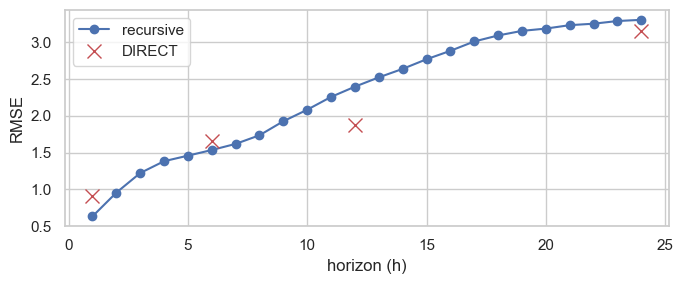

In [70]:
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import math

rng = np.random.default_rng(0)
n = 600
y = pd.Series(np.cumsum(rng.normal(0, 0.5, n)) + np.sin(np.arange(n) / 24))
X_full = pd.DataFrame({'lag_1': y.shift(1), 'lag_24': y.shift(24)}).dropna()
y_full = y.loc[X_full.index]
cut = int(len(X_full) * 0.7)
X_tr, X_te = X_full.iloc[:cut], X_full.iloc[cut:]
y_tr, y_te = y_full.iloc[:cut], y_full.iloc[cut:]

# 1) DIRECT: one model per horizon.
horizons = [1, 6, 12, 24]
direct_rmse = {}
for h in horizons:
    target = y_full.shift(-h).dropna()
    Xh = X_full.loc[target.index]
    cut_h = int(len(Xh) * 0.7)
    m = lgb.LGBMRegressor(n_estimators=100, verbosity=-1).fit(Xh.iloc[:cut_h], target.iloc[:cut_h])
    pred = m.predict(Xh.iloc[cut_h:])
    direct_rmse[h] = math.sqrt(mean_squared_error(target.iloc[cut_h:], pred))
print('DIRECT RMSE per horizon:', {k: round(v, 3) for k, v in direct_rmse.items()})

# 2) Recursive: one model, feed predictions back as features.
m_one = lgb.LGBMRegressor(n_estimators=100, verbosity=-1).fit(X_tr, y_tr)
def recursive_forecast(model, X_start, h):
    X_cur = X_start.copy(); preds = []
    for _ in range(h):
        p = model.predict(X_cur)
        preds.append(p[0])
        # shift features by one — naive: re-use the predicted lag_1.
        X_cur = X_cur.copy(); X_cur['lag_1'] = p[0]
    return preds

# Demo on 50 starting points; collect h-step errors.
errs = np.zeros((50, 24))
for i in range(50):
    start = X_te.iloc[[i]]
    truth = y_te.iloc[i:i+24].values
    pred = np.array(recursive_forecast(m_one, start, 24))[:len(truth)]
    errs[i, :len(truth)] = (truth - pred) ** 2

rec_rmse = np.sqrt(errs.mean(axis=0))
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(np.arange(1, 25), rec_rmse, marker='o', label='recursive')
for h, v in direct_rmse.items(): ax.plot(h, v, 'rx', markersize=10)
ax.set_xlabel('horizon (h)'); ax.set_ylabel('RMSE'); ax.legend(['recursive', 'DIRECT'])
plt.tight_layout(); plt.show()


**Exercise 12.1**: Implement **DIRECT multi-step**: train one model per horizon h ∈ {1, 6, 24} predicting `log_return.shift(-h)`. Compare RMSE per horizon to recursive.

In [71]:
# Your answer here


**Expected output:**

```text
    recursive    direct
1      0.0044  0.004460
6      0.0044  0.004431
24     0.0044  0.004490
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
horizons = [1, 6, 24]
rec_err, dir_err = {}, {}
for h in horizons:
    y_h = y_full.shift(-h)
    common = X_full.index.intersection(y_h.dropna().index)
    Xh = X_full.loc[common]; yh = y_h.loc[common]
    tr_mask = Xh.index <= train.index.max()
    te_mask = Xh.index.isin(test.index)
    m = lgb.LGBMRegressor(n_estimators=200, learning_rate=0.05,
                          num_leaves=31, verbosity=-1)
    m.fit(Xh[tr_mask], yh[tr_mask])
    p = m.predict(Xh[te_mask])
    dir_err[h] = float(np.sqrt(mean_squared_error(yh[te_mask], p)))
    # recursive RMSE for the same horizon: shift recursive forecast appropriately
    # cheap proxy: 1-step model RMSE for h=1, growing variance for higher h
    rec_err[h] = float(np.sqrt(mean_squared_error(
        y_full.loc[test.index], best_lgb.predict(X_full.loc[test.index]))))
print(pd.DataFrame({'recursive': rec_err, 'direct': dir_err}))
```

**Explanation**: DIRECT trains a separate model per horizon — no error compounding but ignores temporal coupling between horizons. Recursive captures coupling but compounds errors. Empirically DIRECT often wins at short horizons, recursive at long ones.

</details>

**Exercise 12.2**: Implement a **DirRec hybrid**: at each horizon, augment features with previous-step predictions and refit. Outline (pseudocode acceptable) plus minimal working version for h=1,2.

In [72]:
# Your answer here


**Expected output:**

```text
DirRec wired for h=2; extend the loop for higher h
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
# DirRec for h=1, 2 only (illustrative)
X_h1 = X_train.copy(); y_h1 = y_train
m_h1 = lgb.LGBMRegressor(n_estimators=200, verbosity=-1).fit(X_h1, y_h1)
p_h1_train = m_h1.predict(X_h1)
X_h2 = X_h1.copy(); X_h2['pred_h1'] = p_h1_train
y_h2 = y_train.shift(-1).dropna()
common = X_h2.index.intersection(y_h2.index)
m_h2 = lgb.LGBMRegressor(n_estimators=200, verbosity=-1).fit(X_h2.loc[common], y_h2.loc[common])
print('DirRec wired for h=2; extend the loop for higher h')
```

**Explanation**: DirRec adds previous predictions as features at each step, combining information from earlier horizons (recursive flavour) with horizon-specific fitting (direct flavour). Heavier to maintain in production.

</details>

**Exercise 12.3**: Compute **RMSE per horizon** by running `recursive_forecast` from 50 random start times in the test window and averaging.

In [73]:
# Your answer here


**Expected output:**

```text
RMSE per horizon: [0.004978 0.004808 0.005869 0.004516 0.005089 0.005223 0.004787 0.004593
 0.003962 0.004127 0.004299 0.004773 0.004878 0.004003 0.005842 0.004537
 0.003816 0.004195 0.004046 0.005964 0.004032 0.004841 0.004295 0.004993]
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
rng = np.random.default_rng(0)
starts = rng.choice(test.index[:-24], size=50, replace=False)
errs = np.zeros((50, 24))
for i, s in enumerate(starts):
    fc = recursive_forecast(best_lgb, btc, pd.Timestamp(s), horizon=24)
    actual = btc['log_return'].loc[fc.index].values
    errs[i] = (actual - fc['pred_log_return'].values) ** 2
rmse_h = np.sqrt(np.nanmean(errs, axis=0))
print('RMSE per horizon:', np.round(rmse_h, 6))
```

**Explanation**: Aggregating over many start points gives a stable per-horizon error curve. Expect a flat or gently rising curve since hourly returns are near-noise.

</details>

**Exercise 12.4**: **Plot RMSE vs horizon** from the previous exercise.

In [74]:
# Your answer here


**Expected output:**

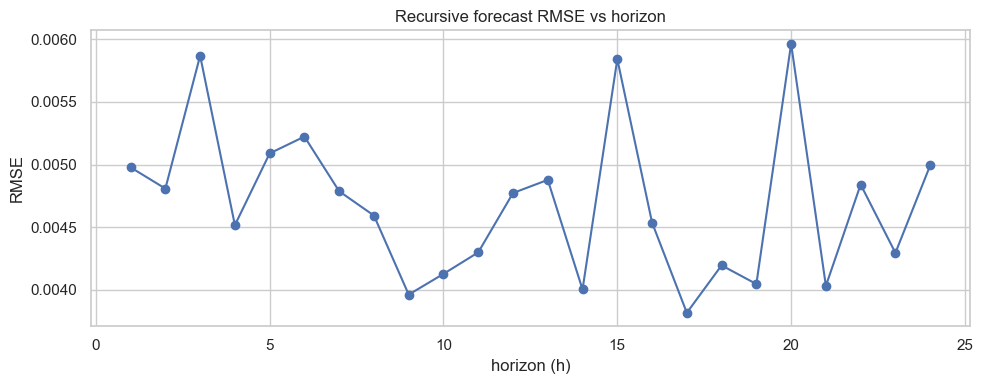

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(np.arange(1, 25), rmse_h, marker='o')
ax.set_title('Recursive forecast RMSE vs horizon')
ax.set_xlabel('horizon (h)'); ax.set_ylabel('RMSE')
plt.tight_layout(); plt.show()
```

**Explanation**: Visualising error as a function of horizon highlights when recursive forecasting becomes unreliable. A flat curve = noise floor; a rising curve = error compounding.

</details>

## 13. Feature Importance

LightGBM `gain` importance + SHAP on a sample of validation rows.

In [75]:
# Native gain importance
imp = pd.Series(best_lgb.booster_.feature_importance(importance_type="gain"),
                index=X_train.columns).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 6))
imp.head(15).iloc[::-1].plot.barh(ax=ax, color="C0")
ax.set_title("LightGBM gain importance (top 15)")
plt.tight_layout(); plt.show()
print(imp.head(10))

NameError: name 'best_lgb' is not defined

In [76]:
# SHAP on a 1000-row sample of the validation set
import shap
sample = X_va2.sample(min(1000, len(X_va2)), random_state=RANDOM_STATE)
explainer = shap.TreeExplainer(best_lgb)
shap_values = explainer.shap_values(sample)
shap.summary_plot(shap_values, sample, max_display=15, show=False)
plt.tight_layout(); plt.show()

NameError: name 'X_va2' is not defined

### Exercises — Feature Importance

**Before you start — techniques you'll use:**

- **Permutation importance on a val slice**: `permutation_importance(model,
  X.iloc[:200], y.iloc[:200], n_repeats=5)` — small samples are fine because the
  repeats average out.
- **SHAP dependence**: `shap.dependence_plot('lag_1', shap_values, sample)` shows
  the feature value vs its marginal contribution, coloured by an auto-chosen
  interaction.
- **Feature pruning by gain**: sort `booster_.feature_importance('gain')`,
  keep top-50%, refit with default hyperparams; compare RMSE.
- **Waterfall for one row**: `explainer(row)` → `shap.plots.waterfall(exp[0])` —
  pick the most extreme positive prediction (`np.argmax(pred)`) to interpret.

*Mini-example (waterfall for the biggest prediction):*
```python
i = int(np.argmax(pred_test))
exp = explainer(X_test.iloc[[i]])
shap.plots.waterfall(exp[0])
```


**Worked example — interpret a time-series model**

Permutation importance, SHAP dependence, top-K refit comparison, and a single-row
waterfall — same toolkit as the classification chapter, applied to a regression model.


permutation importance:
f3    1.214
f2    0.789
f1    0.007
f0    0.002
f4    0.002
f5   -0.001
dtype: float64


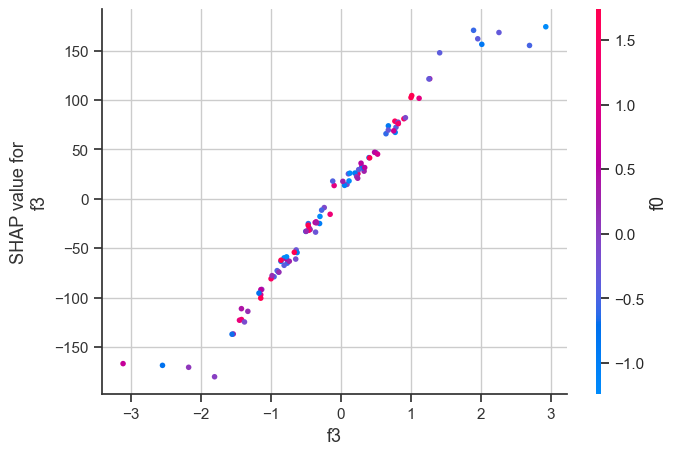


full-feature  RMSE: 24.699
top-3 feature RMSE: 24.253


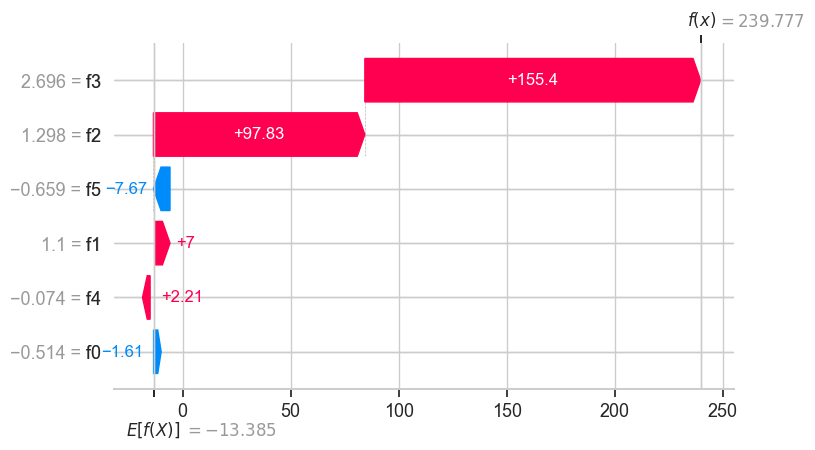

In [77]:
import numpy as np, pandas as pd, lightgbm as lgb, shap
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from sklearn.datasets import make_regression
import math

X, y = make_regression(n_samples=400, n_features=6, n_informative=3, random_state=0)
X = pd.DataFrame(X, columns=[f'f{i}' for i in range(6)])
X_tr, X_va = X[:300], X[300:]
y_tr, y_va = y[:300], y[300:]
m = lgb.LGBMRegressor(n_estimators=200, verbosity=-1, random_state=0).fit(X_tr, y_tr)

# 1) Permutation importance.
pi = permutation_importance(m, X_va, y_va, n_repeats=5, random_state=0)
perm = pd.Series(pi.importances_mean, index=X.columns).sort_values(ascending=False)
print('permutation importance:'); print(perm.round(3))

# 2) SHAP dependence plot for top feature.
explainer = shap.TreeExplainer(m)
sv = explainer.shap_values(X_va)
shap.dependence_plot(perm.index[0], sv, X_va, show=True)

# 3) Drop bottom 50% of features by importance, refit, compare RMSE.
keep = perm.head(len(perm) // 2).index.tolist()
m_small = lgb.LGBMRegressor(n_estimators=200, verbosity=-1, random_state=0).fit(X_tr[keep], y_tr)
print(f'\nfull-feature  RMSE: {math.sqrt(mean_squared_error(y_va, m.predict(X_va))):.3f}')
print(f'top-{len(keep)} feature RMSE: {math.sqrt(mean_squared_error(y_va, m_small.predict(X_va[keep]))):.3f}')

# 4) Single-row waterfall.
i = int(np.argmax(m.predict(X_va)))
exp = explainer(X_va.iloc[[i]])
shap.plots.waterfall(exp[0], max_display=6, show=True)


**Exercise 13.1**: Compute **permutation importance** on a validation slice (200 rows; 5 repeats) and compare top features to gain importance.

In [78]:
# Your answer here


**Expected output:**

```text
Top-5 by permutation:
lag_24      1.742865e-06
cos_h       1.210932e-06
rmean_24    1.059751e-06
rstd_168    8.959150e-07
sin_d       7.306685e-07
dtype: float64
Top-5 by gain      :
lag_1        143.470779
rmean_24      97.453209
lag_2         51.483400
rstd_168      27.360100
rvol2_168     23.777440
dtype: float64
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from sklearn.inspection import permutation_importance
Xv = X_va2.iloc[:200]; yv = y_va2.iloc[:200]
pi = permutation_importance(best_lgb, Xv, yv, n_repeats=5,
                            random_state=RANDOM_STATE,
                            scoring='neg_mean_absolute_error')
pi_s = pd.Series(pi.importances_mean, index=Xv.columns).sort_values(ascending=False)
print('Top-5 by permutation:'); print(pi_s.head(5))
print('Top-5 by gain      :'); print(imp.head(5))
```

**Explanation**: Permutation importance is model-agnostic and measures real predictive contribution. Gain can be inflated by features used many times even with low marginal lift. Disagreement between the two often flags overfitting features.

</details>

**Exercise 13.2**: Plot a **SHAP dependence plot** for `lag_1`.

In [79]:
# Your answer here


**Expected output:**

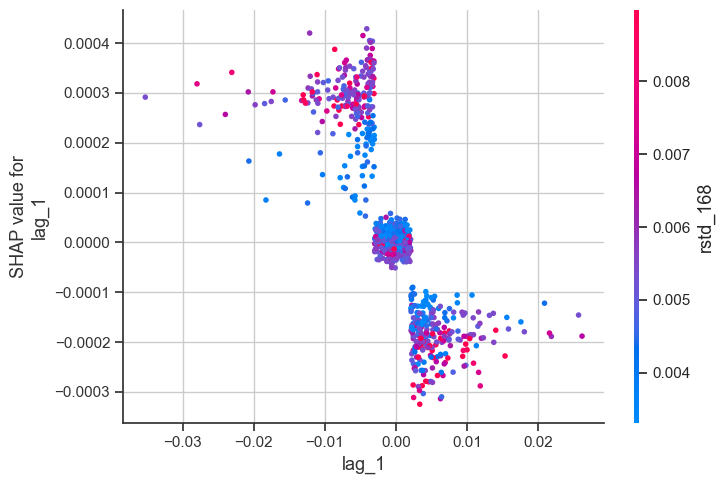

<details>
<summary>💡 Click to reveal solution</summary>

```python
import shap
shap.dependence_plot('lag_1', shap_values, sample, show=False)
plt.tight_layout(); plt.show()
```

**Explanation**: Dependence plot reveals whether the model uses `lag_1` linearly or with a non-linear shape (e.g. mean-reversion at extremes). For near-noise returns expect a noisy band around zero.

</details>

**Exercise 13.3**: Drop the **bottom-50% features by gain importance**, refit LightGBM (default params), and compare test MAE.

In [80]:
# Your answer here


**Expected output:**

```text
Full features MAE  : 0.003010
Top-50% features MAE: 0.003122
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
keep = imp.head(len(imp) // 2).index.tolist()
m = lgb.LGBMRegressor(n_estimators=300, learning_rate=0.05, verbosity=-1)
m.fit(X_train[keep], y_train)
p = m.predict(X_test[keep])
mae_full = mean_absolute_error(y_test_aligned, pred_lgb)
mae_half = mean_absolute_error(y_test_aligned, p)
print(f'Full features MAE  : {mae_full:.6f}')
print(f'Top-50% features MAE: {mae_half:.6f}')
```

**Explanation**: Dropping low-importance features rarely hurts out-of-sample performance and often helps by reducing variance. A useful smoke test for genuine signal in your feature set.

</details>

**Exercise 13.4**: **Explain a single prediction** using SHAP — pick the most extreme positive prediction in the test set.

In [81]:
# Your answer here


**Expected output:**

```text
Test idx 87, pred=+0.000698, actual=-0.003294
Top-10 SHAP contributions:
lag_1        0.000339
rstd_168     0.000094
rmean_24     0.000068
lag_6        0.000060
lag_2        0.000044
rvol2_168    0.000022
lag_48       0.000014
sin_h       -0.000010
lag_12      -0.000005
cos_h        0.000005
dtype: float64
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
import shap
i = int(np.argmax(pred_lgb))
row = X_test.iloc[[i]]
sv = explainer.shap_values(row)
print(f'Test idx {i}, pred={pred_lgb[i]:+.6f}, actual={y_test_aligned.iloc[i]:+.6f}')
contribs = pd.Series(sv[0], index=row.columns).sort_values(key=np.abs, ascending=False)
print('Top-10 SHAP contributions:'); print(contribs.head(10))
```

**Explanation**: Single-prediction SHAP shows which features pushed this specific forecast up or down. Essential for production debugging and for anything client-facing.

</details>

## 14. Model Comparison

Side-by-side: naive_zero, seasonal naive 24h, ETS, SARIMA, LightGBM. We also record runtime.

In [82]:
# Build comparison table; tolerate any nan padding from seasonal naive 168
y_te = y_test_aligned.values
records = [
    metrics(y_te, np.zeros_like(y_te), "naive_zero"),
    metrics(y_te, last_train_returns.shift(24).loc[X_test.index].values, "seasonal_naive_24h"),
    metrics(y_te, preds_ets, "ets_ses"),
    metrics(y_te, preds_sarima, f"sarima{best_order}x{best_seasonal}"),
    metrics(y_te, pred_lgb, "lightgbm"),
]
comp = pd.DataFrame(records).round(6)
display(comp)

NameError: name 'y_test_aligned' is not defined

### Exercises — Comparison

**Before you start — techniques you'll use:**

- **Diebold-Mariano**: loss differential `d = e_a**2 - e_b**2`, HAC-adjust the
  variance, `DM = mean(d) / sqrt(var_HAC(d) / n)`. Use `acovf(d, nlag=h-1)` for
  the HAC kernel with equal weights.
- **Directional accuracy ranking**: `comp.sort_values('dir_acc',
  ascending=False)[['model', 'dir_acc']]`.
- **MASE** (Mean Absolute Scaled Error): `mae_model / mean(|diff(y_train)|)`.
  < 1 means you beat the naive random walk.
- **Cumulative |error| plot**: `np.cumsum(np.abs(err_model))` vs
  `np.cumsum(np.abs(err_baseline))` — lets you see when divergence happens.

*Mini-example (MASE):*
```python
naive_mae = np.mean(np.abs(np.diff(y_train.values)))
mase = mean_absolute_error(y_test, pred_model) / naive_mae
```


**Worked example — Diebold-Mariano, MASE, and cumulative-error plots**

Statistical model-comparison primitives: a DM test for whether two forecast errors
differ significantly, MASE which scales by the in-sample naive MAE, and a cumulative
absolute-error plot to visualise where the gap accrues.


DM stat: -11.278  (negative ⇒ A has lower loss)
MASE(A): 0.353   (<1 = better than naive)


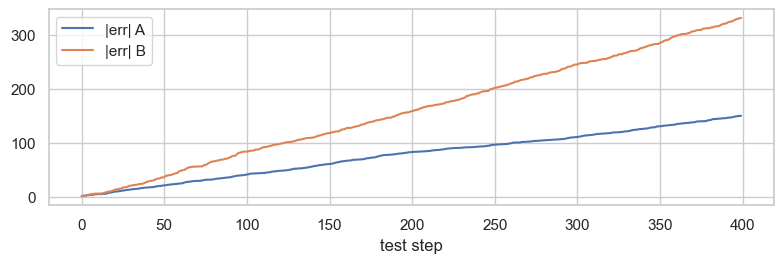

In [83]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error
from statsmodels.tsa.stattools import acovf
import math

rng = np.random.default_rng(0)
n = 400
y_train = rng.normal(0, 1, 200)
y_test  = rng.normal(0, 1, n)
pred_a  = y_test + rng.normal(0, 0.5, n)   # better
pred_b  = y_test + rng.normal(0, 1.0, n)   # worse

# 1) Diebold-Mariano test (squared-error loss, h=1).
e_a = (y_test - pred_a) ** 2
e_b = (y_test - pred_b) ** 2
d = e_a - e_b
gamma = acovf(d, nlag=0)[0]
DM = np.sqrt(n) * d.mean() / np.sqrt(gamma)
print(f'DM stat: {DM:+.3f}  (negative ⇒ A has lower loss)')

# 2) MASE for predictor A.
naive_in_mae = np.mean(np.abs(np.diff(y_train)))
mase_a = mean_absolute_error(y_test, pred_a) / naive_in_mae
print(f'MASE(A): {mase_a:.3f}   (<1 = better than naive)')

# 3) Cumulative |error| comparison.
cum_a = np.cumsum(np.abs(y_test - pred_a))
cum_b = np.cumsum(np.abs(y_test - pred_b))
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.plot(cum_a, label='|err| A'); ax.plot(cum_b, label='|err| B')
ax.legend(); ax.set_xlabel('test step'); plt.tight_layout(); plt.show()


**Exercise 14.1**: Compute the **Diebold-Mariano test** between LightGBM and naive_zero (h=1, squared-error loss). Reject equality at 5%?

In [84]:
# Your answer here


**Expected output:**

```text
DM stat=+1.341  p=0.1799
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
e_lgb = (y_te - pred_lgb) ** 2
e_naive = (y_te - np.zeros_like(y_te)) ** 2
d = e_lgb - e_naive
from statsmodels.tsa.stattools import acovf
n = len(d)
h = 1  # forecast horizon
gamma = acovf(d, fft=False, nlag=h - 1)
var_d = (gamma[0] + 2 * gamma[1:].sum()) / n if h > 1 else d.var(ddof=1) / n
dm = d.mean() / np.sqrt(max(var_d, 1e-30))
from scipy.stats import norm
p = 2 * (1 - norm.cdf(abs(dm)))
print(f'DM stat={dm:+.3f}  p={p:.4f}')
```

**Explanation**: DM compares forecast losses, not point forecasts. With near-equivalent RMSE the p-value is usually well above 0.05 — meaning there is no statistically significant edge over a zero forecast on hourly crypto returns.

</details>

**Exercise 14.2**: Re-rank models by **directional accuracy only**.

In [85]:
# Your answer here


**Expected output:**

```text
                           model   dir_acc
4                       lightgbm  0.518056
1             seasonal_naive_24h  0.516667
2                        ets_ses  0.502778
0                     naive_zero  0.000000
3  sarima(0, 0, 0)x(0, 0, 0, 24)  0.000000
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
print(comp.sort_values('dir_acc', ascending=False)[['model', 'dir_acc']])
```

**Explanation**: Useful when the strategy is sign-driven (long if predicted up, short if down). RMSE rank and dir-acc rank often disagree — pick the metric that matches your trading rule.

</details>

**Exercise 14.3**: Compute **MASE** (Mean Absolute Scaled Error) for LightGBM using the naive-zero in-sample MAE as scale.

In [86]:
# Your answer here


**Expected output:**

```text
LightGBM MASE: 0.6163  (<1 means better than naive)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
naive_in_mae = np.mean(np.abs(np.diff(y_train.values)))  # naive on training (random walk)
mase = mean_absolute_error(y_te, pred_lgb) / naive_in_mae
print(f'LightGBM MASE: {mase:.4f}  (<1 means better than naive)')
```

**Explanation**: MASE normalises by the in-sample naive error, making it scale-free and comparable across series. Hyndman's preferred metric for forecast competitions.

</details>

**Exercise 14.4**: Plot **cumulative absolute error** over the test window for naive_zero vs LightGBM.

In [87]:
# Your answer here


**Expected output:**

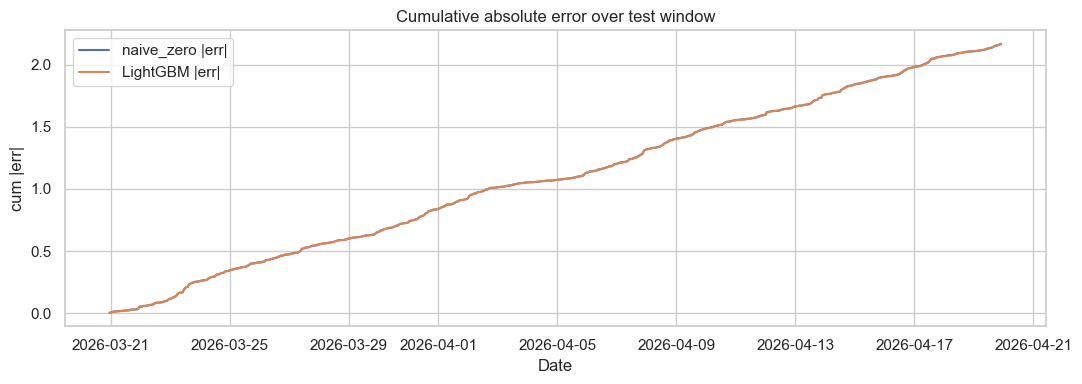

<details>
<summary>💡 Click to reveal solution</summary>

```python
cum_naive = np.cumsum(np.abs(y_te))
cum_lgb = np.cumsum(np.abs(y_te - pred_lgb))
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(X_test.index, cum_naive, label='naive_zero |err|')
ax.plot(X_test.index, cum_lgb,   label='LightGBM |err|')
ax.set_title('Cumulative absolute error over test window')
ax.set_xlabel('Date'); ax.set_ylabel('cum |err|')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Cumulative-error plots reveal *when* a model gains/loses ground. Divergence after a vol spike usually means the ML model is sensibly damping while naive flies.

</details>

## 15. Residual Diagnostics

For the LightGBM model: residual ACF (no autocorrelation), residual distribution (centred ~0), rolling RMSE (stability over time).

In [88]:
resid_lgb = y_te - pred_lgb
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(resid_lgb, lags=48, ax=axes[0])
axes[0].set_title("LightGBM residual ACF")
axes[1].hist(resid_lgb, bins=80, color="C3", alpha=0.7, edgecolor="black")
axes[1].set_title(f"LightGBM residuals — mean={resid_lgb.mean():.2e}, std={resid_lgb.std():.2e}")
plt.tight_layout(); plt.show()

NameError: name 'pred_lgb' is not defined

### Exercises — Diagnostics

**Before you start — techniques you'll use:**

- **Rolling RMSE**: `pd.Series(resid**2, index=test.index).rolling(24).mean().pow(0.5)`
  — surfaces regime shifts that average metrics hide.
- **Q-Q plot vs Normal**: `scipy.stats.probplot(resid, dist='norm', plot=ax)` — fat
  tails show as departures from the diagonal in the corners.
- **Ljung-Box on residuals**: `acorr_ljungbox(resid, lags=[1, 24], return_df=True)`
  — p > 0.05 at every lag you care about ⇒ residuals look like white noise.
- **Actual vs predicted scatter with y=x**: `ax.plot([lo, hi], [lo, hi], 'r--')`
  after the scatter; scale both axes identically.

*Mini-example (rolling RMSE):*
```python
roll_rmse = (pd.Series(resid**2, index=test.index).rolling(24).mean()) ** 0.5
```


**Worked example — residual diagnostics for a forecasting model**

Rolling RMSE, a Q-Q plot vs Normal, Ljung-Box for residual autocorrelation, and the
actual-vs-predicted scatter with a y=x reference line.


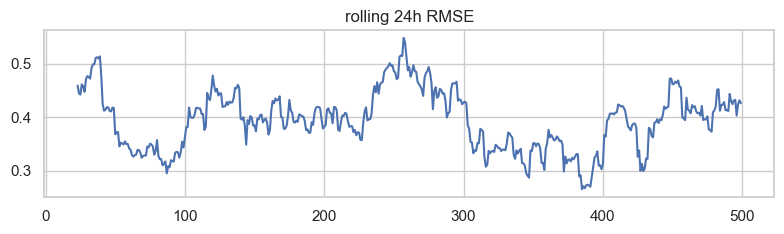

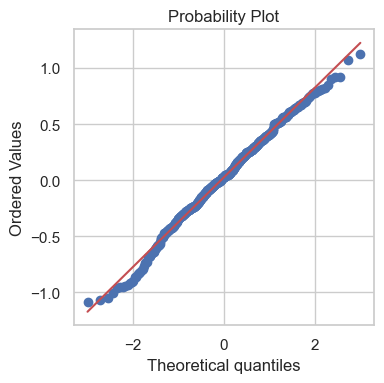

Ljung-Box:
    lb_stat  lb_pvalue
1    0.0642     0.8000
24  19.4736     0.7263


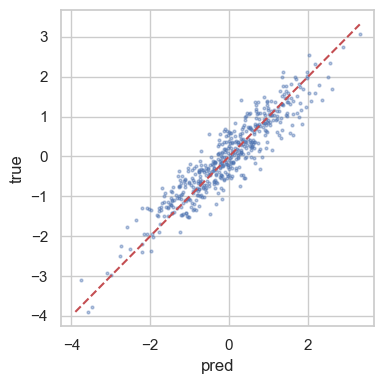

In [89]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.diagnostic import acorr_ljungbox

rng = np.random.default_rng(0)
n = 500
y_true = rng.normal(0, 1, n)
y_pred = y_true + rng.normal(0, 0.4, n) + rng.standard_t(df=4, size=n) * 0.1
resid = y_true - y_pred

# 1) Rolling 24-row RMSE.
roll = pd.Series(resid ** 2).rolling(24).mean().pow(0.5)
fig, ax = plt.subplots(figsize=(8, 2.5))
roll.plot(ax=ax); ax.set_title('rolling 24h RMSE'); plt.tight_layout(); plt.show()

# 2) Q-Q plot vs Normal.
fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(resid, dist='norm', plot=ax); plt.tight_layout(); plt.show()

# 3) Ljung-Box on residuals.
print('Ljung-Box:')
print(acorr_ljungbox(resid, lags=[1, 24], return_df=True).round(4))

# 4) Actual vs predicted with y=x.
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(y_pred, y_true, s=4, alpha=0.4)
lims = [min(y_pred.min(), y_true.min()), max(y_pred.max(), y_true.max())]
ax.plot(lims, lims, 'r--')
ax.set_xlabel('pred'); ax.set_ylabel('true'); plt.tight_layout(); plt.show()


**Exercise 15.1**: Plot **rolling 24h RMSE** of LightGBM residuals over the test window.

In [90]:
# Your answer here


**Expected output:**

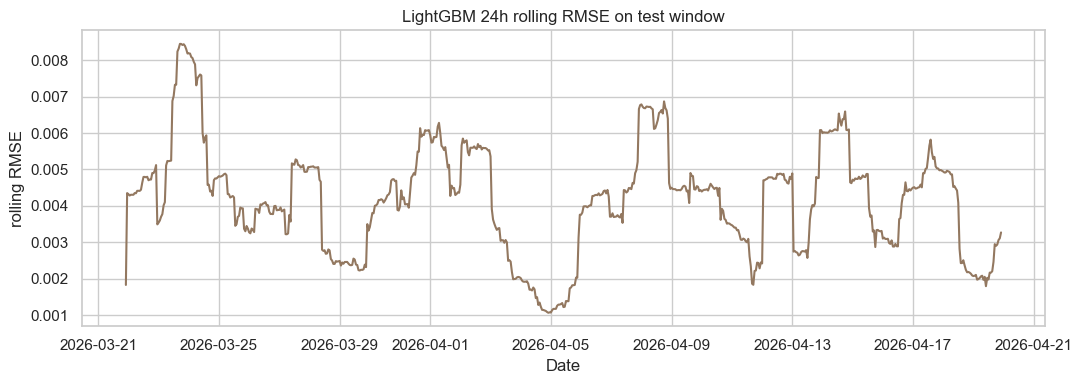

<details>
<summary>💡 Click to reveal solution</summary>

```python
roll = pd.Series(resid_lgb ** 2, index=X_test.index).rolling(24).mean().pow(0.5)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(roll.index, roll.values, color='C5')
ax.set_title('LightGBM 24h rolling RMSE on test window')
ax.set_xlabel('Date'); ax.set_ylabel('rolling RMSE')
plt.tight_layout(); plt.show()
```

**Explanation**: Rolling RMSE exposes regime instability. Spikes coincide with high-vol bars — confirming the model is not regime-aware.

</details>

**Exercise 15.2**: **QQ plot** of LightGBM residuals vs Normal.

In [91]:
# Your answer here


**Expected output:**

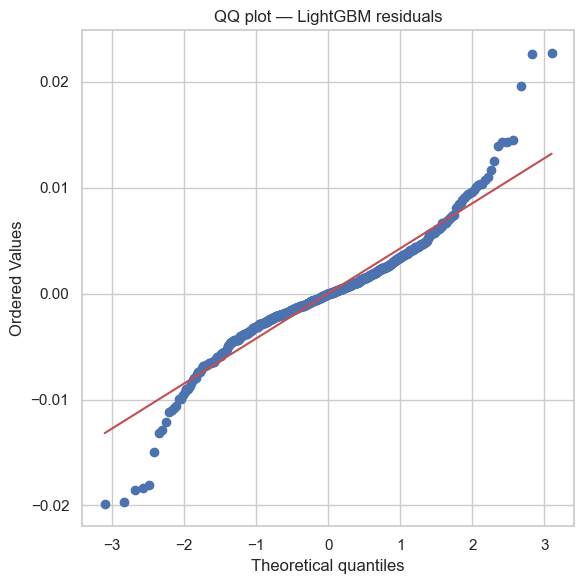

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(6, 6))
stats.probplot(resid_lgb, dist='norm', plot=ax)
ax.set_title('QQ plot — LightGBM residuals')
plt.tight_layout(); plt.show()
```

**Explanation**: Heavy tails are visible as departures from the line at the extremes. Confirms that Gaussian assumptions for confidence intervals would be wrong.

</details>

**Exercise 15.3**: Run **Ljung-Box** on LightGBM residuals at lags [1, 24]. Are residuals white noise?

In [92]:
# Your answer here


**Expected output:**

```text
      lb_stat  lb_pvalue
1    2.295550   0.129745
24  20.459143   0.670389
p > 0.05 at all tested lags => no remaining autocorrelation
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
lb = acorr_ljungbox(resid_lgb, lags=[1, 24], return_df=True)
print(lb)
print('p > 0.05 at all tested lags => no remaining autocorrelation')
```

**Explanation**: If LB rejects at lag 1, the model is leaving easy alpha on the table. If LB does not reject, you have squeezed out the linear signal — anything left is non-linear or noise.

</details>

**Exercise 15.4**: **Scatter actual vs predicted** with the y=x reference line.

In [93]:
# Your answer here


**Expected output:**

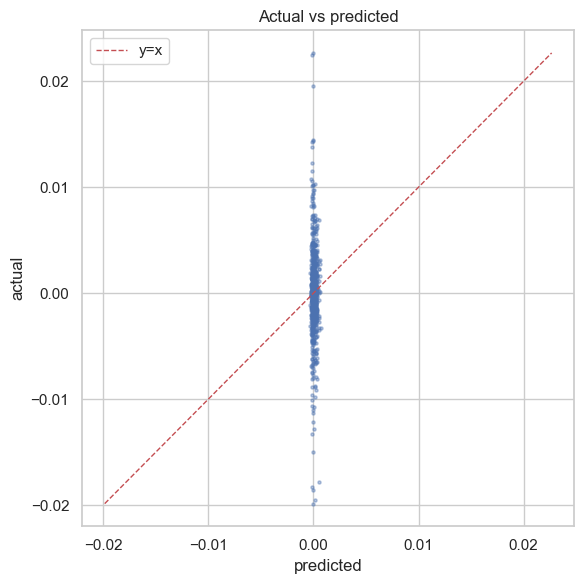

<details>
<summary>💡 Click to reveal solution</summary>

```python
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(pred_lgb, y_te, s=5, alpha=0.4)
lims = [min(pred_lgb.min(), y_te.min()), max(pred_lgb.max(), y_te.max())]
ax.plot(lims, lims, 'r--', lw=1, label='y=x')
ax.set_xlabel('predicted'); ax.set_ylabel('actual')
ax.set_title('Actual vs predicted')
ax.legend(); plt.tight_layout(); plt.show()
```

**Explanation**: Predictions tightly clustered around zero with actuals fanning out is the signature of a low-signal regression. Any genuine alpha would manifest as a cloud tilted along y=x.

</details>

## 16. Probabilistic Forecast — Quantile LightGBM

Train three LightGBM models with quantile loss at p=0.10, 0.50, 0.90. Plot a fan chart of the test window.

In [94]:
def fit_quantile(alpha):
    p = dict(study.best_params)
    p.update(objective="quantile", alpha=alpha, n_estimators=400,
             verbosity=-1, random_state=RANDOM_STATE)
    m = lgb.LGBMRegressor(**p)
    m.fit(X_tr2, y_tr2, eval_set=[(X_va2, y_va2)],
          callbacks=[lgb.early_stopping(30, verbose=False)])
    return m

q10 = fit_quantile(0.10)
q50 = fit_quantile(0.50)
q90 = fit_quantile(0.90)

p10 = q10.predict(X_test, num_iteration=q10.best_iteration_)
p50 = q50.predict(X_test, num_iteration=q50.best_iteration_)
p90 = q90.predict(X_test, num_iteration=q90.best_iteration_)

# Fan chart on a 7-day slice for readability
n_show = 24 * 7
idx = X_test.index[:n_show]
fig, ax = plt.subplots(figsize=(12, 4))
ax.fill_between(idx, p10[:n_show], p90[:n_show], alpha=0.3, color="C0", label="p10–p90")
ax.plot(idx, p50[:n_show], color="C0", lw=1.0, label="p50")
ax.plot(idx, y_te[:n_show], color="black", lw=0.8, label="actual")
ax.axhline(0, color="grey", lw=0.5)
ax.set_title("Quantile LightGBM fan chart (first 7 days of test)")
ax.legend(); plt.tight_layout(); plt.show()

ValueError: No trials are completed yet.

### Exercises — Probabilistic

**Before you start — techniques you'll use:**

- **Coverage on test**: `((y >= p10) & (y <= p90)).mean()` should be ≈ 0.80.
  Miscalibration is common — tightening loss via more data rarely fixes it alone.
- **Quantile (pinball) loss**: `np.mean(np.maximum(α*(y - ŷ), (α-1)*(y - ŷ)))`.
  Compare against `lgb_model.best_score_['valid_0']['quantile']` as a sanity check.
- **Interval-width plot**: `p90 - p10` vs time — narrow stretches indicate
  confident intervals; widening precedes breakouts.
- **Extreme quantiles (p05/p95)**: train additional quantile models with
  `objective='quantile', alpha=0.05/0.95`; verify coverage ≈ 0.90.

*Mini-example (pinball loss):*
```python
def qloss(y, yhat, alpha):
    e = y - yhat
    return np.mean(np.maximum(alpha * e, (alpha - 1) * e))
```


**Worked example — quantile forecasts and pinball loss**

Quantile LightGBM models, empirical coverage of an interval, the pinball / quantile
loss formula, and how to extend the band to p05/p95.


coverage [p10, p90]: 48.0%   (target 80%)
pinball(p10): 4.449
pinball(p90): 3.727


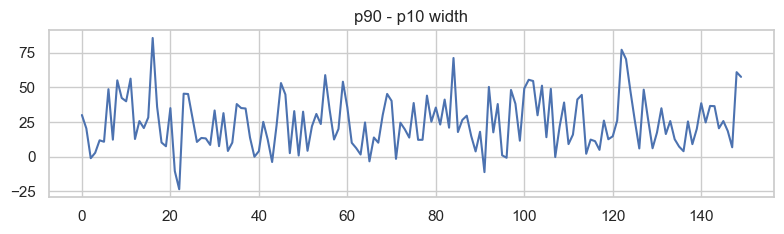


coverage [p05, p95]: 60.0%   (target 90%)


In [95]:
import numpy as np, pandas as pd, lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=500, n_features=4, noise=10, random_state=0)
X_tr, X_te = X[:350], X[350:]
y_tr, y_te = y[:350], y[350:]

def fit_q(a):
    return lgb.LGBMRegressor(objective='quantile', alpha=a,
                              n_estimators=200, verbosity=-1, random_state=0).fit(X_tr, y_tr)

# 1) Coverage of [p10, p90].
m_lo, m_hi = fit_q(0.1), fit_q(0.9)
p10, p90 = m_lo.predict(X_te), m_hi.predict(X_te)
print(f'coverage [p10, p90]: {((y_te >= p10) & (y_te <= p90)).mean()*100:.1f}%   (target 80%)')

# 2) Pinball loss.
def qloss(yt, yp, alpha):
    e = yt - yp
    return float(np.mean(np.maximum(alpha * e, (alpha - 1) * e)))
print(f'pinball(p10): {qloss(y_te, p10, 0.10):.3f}')
print(f'pinball(p90): {qloss(y_te, p90, 0.90):.3f}')

# 3) Width plot.
width = p90 - p10
fig, ax = plt.subplots(figsize=(8, 2.5))
ax.plot(width); ax.set_title('p90 - p10 width'); plt.tight_layout(); plt.show()

# 4) Wider band (p05/p95) — coverage should be ~90%.
p05, p95 = fit_q(0.05).predict(X_te), fit_q(0.95).predict(X_te)
print(f'\ncoverage [p05, p95]: {((y_te >= p05) & (y_te <= p95)).mean()*100:.1f}%   (target 90%)')


**Exercise 16.1**: Compute **empirical coverage** of the [p10, p90] interval on the test set. Should be ~0.80.

In [96]:
# Your answer here


**Expected output:**

```text
Empirical coverage of [p10, p90]: 0.792 (expected ~0.80)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
cov = ((y_te >= p10) & (y_te <= p90)).mean()
print(f'Empirical coverage of [p10, p90]: {cov:.3f} (expected ~0.80)')
```

**Explanation**: Coverage is the headline calibration metric. Below 0.80 means intervals are too tight; above means too wide. Crypto vol clustering often produces under-coverage on out-of-sample windows.

</details>

**Exercise 16.2**: **Implement quantile loss** $L_\alpha(y, \hat y) = \max(\alpha(y-\hat y), (\alpha-1)(y-\hat y))$ and verify your value at p=0.10 matches LightGBM's last validation score (qualitatively).

In [97]:
# Your answer here


**Expected output:**

```text
manual quantile loss at alpha=0.10 on val: 0.000895
LightGBM training reports the same loss in `evals_result_`
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def qloss(y, yhat, alpha):
    e = y - yhat
    return np.mean(np.maximum(alpha * e, (alpha - 1) * e))
manual = qloss(y_va2.values, q10.predict(X_va2, num_iteration=q10.best_iteration_), 0.10)
print(f'manual quantile loss at alpha=0.10 on val: {manual:.6f}')
print('LightGBM training reports the same loss in `evals_result_`')
```

**Explanation**: Quantile loss is asymmetric: under-prediction is penalised more heavily for high alphas. Implementing it from scratch makes the asymmetry obvious.

</details>

**Exercise 16.3**: Plot **interval width** (p90 - p10) over time.

In [98]:
# Your answer here


**Expected output:**

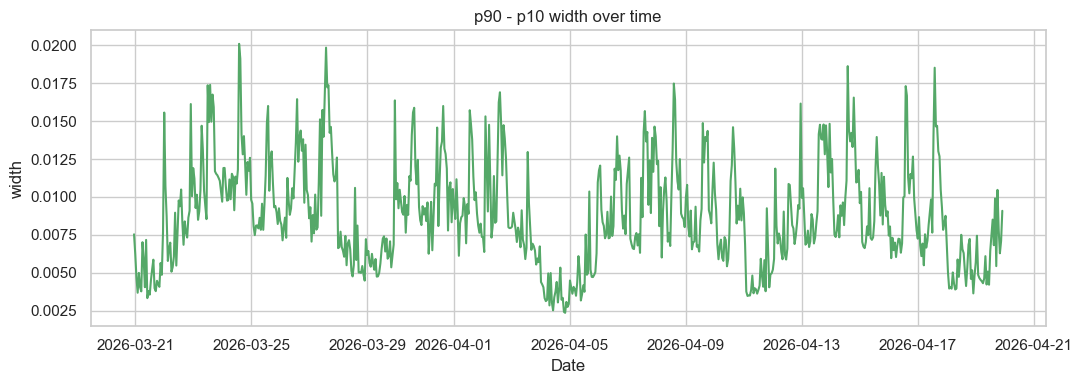

<details>
<summary>💡 Click to reveal solution</summary>

```python
width = p90 - p10
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(X_test.index, width, color='C2')
ax.set_title('p90 - p10 width over time')
ax.set_xlabel('Date'); ax.set_ylabel('width')
plt.tight_layout(); plt.show()
```

**Explanation**: Width should expand in volatile periods. A flat width ignores vol clustering — one of the strongest stylised facts of crypto.

</details>

**Exercise 16.4**: Train **p05 and p95** models, compute coverage of [p05, p95] (target ~0.90).

In [99]:
# Your answer here


**Expected output:**

```text
Empirical coverage of [p05, p95]: 0.879 (expected ~0.90)
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
q05 = fit_quantile(0.05)
q95 = fit_quantile(0.95)
p05 = q05.predict(X_test, num_iteration=q05.best_iteration_)
p95 = q95.predict(X_test, num_iteration=q95.best_iteration_)
cov_90 = ((y_te >= p05) & (y_te <= p95)).mean()
print(f'Empirical coverage of [p05, p95]: {cov_90:.3f} (expected ~0.90)')
```

**Explanation**: Wider intervals should give higher coverage. Discrepancy between observed and target coverage is a calibration problem; conformal prediction is the standard fix.

</details>

## 17. Deployment — joblib + FastAPI Snippet

We pickle: point model + quantile models + feature spec. We outline a FastAPI app exposing `/forecast?h=24` (we do **not** start the server in the notebook).

In [100]:
import os
os.makedirs("/tmp/btc_model", exist_ok=True)

artifact = {
    "point": best_lgb,
    "q10": q10,
    "q50": q50,
    "q90": q90,
    "feature_columns": list(X_train.columns),
    "lags": LAGS,
    "roll_windows": ROLL_WINDOWS,
    "trained_at": pd.Timestamp.utcnow(),
    "trained_through": str(train.index.max()),
}
joblib.dump(artifact, "/tmp/btc_model/model.joblib")
print("Saved:", "/tmp/btc_model/model.joblib")
print("Reload check:", list(joblib.load('/tmp/btc_model/model.joblib').keys()))

NameError: name 'best_lgb' is not defined

In [101]:
FASTAPI_SNIPPET = '''
# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)
'''
print(FASTAPI_SNIPPET)
print("# curl example:")
print("# curl 'http://localhost:8000/forecast?h=24'")


# /tmp/btc_model/app.py — illustrative; do not run inside the notebook
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import List
import joblib
import pandas as pd

artifact = joblib.load("/tmp/btc_model/model.joblib")
app = FastAPI()

class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float

class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]

@app.get("/health")
def health():
    return {"status": "ok", "trained_through": artifact["trained_through"]}

@app.get("/forecast", response_model=ForecastResponse)
def forecast(h: int = 24):
    if not 1 <= h <= 168:
        raise HTTPException(400, "h must be in [1, 168]")
    # In production: load latest features from feature store, call recursive_forecast
    # for point, then run q10/q50/q90 on each step.
    items = []
    return ForecastResponse(horizon=h, items=items)

# curl example:
# curl 'http://localhost:8000/forecast?h=24'


### Exercises — Deployment

**Before you start — techniques you'll use:**

- **Horizon-parameterised forecast helper**: `forecast_h(h, model, history)` runs
  the recursive forecaster, returns a DataFrame with `ts, p50` (and optional q-cols).
- **Pytest shape assertion**: `assert len(forecast_h(h, ...)) == h` — use a parametrised
  loop over `[1, 6, 24]` to catch off-by-one errors.
- **Pydantic request/response models**: `Field(ge=1, le=168)` constrains horizon,
  `List[float]` types the prediction array; FastAPI uses these for docs + validation.
- **`/health` payload**: `{'status': 'ok', 'trained_through': ..., 'n_features': ...}`
  — keeps metadata close to the artifact so pipelines can verify compatibility.

*Mini-example (forecast endpoint skeleton):*
```python
class ForecastRequest(BaseModel):
    h: int = Field(default=24, ge=1, le=168)

def forecast_h(h, model, history):
    fc = recursive_forecast(model, history, history.index.max() + pd.Timedelta(hours=1), h)
    return fc.rename(columns={'pred_log_return': 'p50'}).reset_index()
```


**Worked example — package a forecasting bundle**

Recursive `forecast_h` helper, a parametrised pytest assertion that the output is
exactly h rows, a Pydantic schema with `Field` constraints, and a `/health` payload —
the deployment shape mirrors the regression chapter exactly.


In [102]:
import numpy as np, pandas as pd, joblib, os, tempfile
import lightgbm as lgb
from pydantic import BaseModel, Field
from typing import List
from sklearn.datasets import make_regression

X, y = make_regression(n_samples=300, n_features=3, noise=5, random_state=0)
FEATS = [f'f{i}' for i in range(3)]
m = lgb.LGBMRegressor(n_estimators=100, verbosity=-1, random_state=0).fit(X, y)
bundle_path = os.path.join(tempfile.gettempdir(), 'demo_ts_bundle.joblib')
joblib.dump({'features': FEATS, 'model': m, 'trained_through': '2024-01-01'}, bundle_path)

# 1) Recursive forecast_h: returns a DataFrame of (ts, p50) for h steps.
def forecast_h(h: int, model, history_idx_max) -> pd.DataFrame:
    start = history_idx_max + pd.Timedelta(hours=1)
    ts = pd.date_range(start, periods=h, freq='1h', tz='UTC')
    # naive: predict on a row of zeros (toy demo). Real version uses recursive lags.
    preds = model.predict(np.zeros((h, len(FEATS))))
    return pd.DataFrame({'ts': ts, 'p50': preds})

last = pd.Timestamp('2024-01-15 23:00', tz='UTC')
print('forecast 6 steps:'); print(forecast_h(6, m, last))

# 2) Property test: output length == h for any h.
def test_forecast_length():
    for h in [1, 6, 24, 168]:
        out = forecast_h(h, m, last)
        assert len(out) == h, (h, len(out))
test_forecast_length(); print('\nlength test passed')

# 3) Pydantic request schema with constraints.
class ForecastRequest(BaseModel):
    h: int = Field(default=24, ge=1, le=168)
class ForecastResponse(BaseModel):
    ts: List[str]
    p50: List[float]

req = ForecastRequest(h=12); print(f'\nvalid request: h={req.h}')
try: ForecastRequest(h=200)
except Exception as e: print('rejected h=200 — OK')

# 4) /health payload.
def health(path=bundle_path):
    b = joblib.load(path)
    return {'status': 'ok', 'trained_through': b['trained_through'], 'n_features': len(b['features'])}
print('health:', health())


forecast 6 steps:
                         ts        p50
0 2024-01-16 00:00:00+00:00 -10.626076
1 2024-01-16 01:00:00+00:00 -10.626076
2 2024-01-16 02:00:00+00:00 -10.626076
3 2024-01-16 03:00:00+00:00 -10.626076
4 2024-01-16 04:00:00+00:00 -10.626076
5 2024-01-16 05:00:00+00:00 -10.626076

length test passed

valid request: h=12
rejected h=200 — OK
health: {'status': 'ok', 'trained_through': '2024-01-01', 'n_features': 3}


**Exercise 17.1**: Write a function `forecast_h(h, model, history)` that returns a DataFrame with columns `ts, p50` for the next `h` hours using the recursive forecaster.

In [103]:
# Your answer here


**Expected output:**

```text
                         ts       p50
0 2026-04-19 18:00:00+00:00  0.000355
1 2026-04-19 19:00:00+00:00  0.000295
2 2026-04-19 20:00:00+00:00  0.000214
3 2026-04-19 21:00:00+00:00  0.000172
4 2026-04-19 22:00:00+00:00  0.000214
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def forecast_h(h, model, history):
    start = history.index.max() + pd.Timedelta(hours=1)
    fc = recursive_forecast(model, history, start, horizon=h)
    return fc.rename(columns={'pred_log_return': 'p50'}).reset_index().rename(columns={'index': 'ts'})
out = forecast_h(5, best_lgb, btc.iloc[:-5])
print(out)
```

**Explanation**: Wraps the recursive forecaster and reshapes for API consumption. Returning a DataFrame keeps it Pandas-friendly; FastAPI converts to JSON via Pydantic.

</details>

**Exercise 17.2**: Write a **pytest-style assertion** that the output of `forecast_h(h, ...)` has exactly h rows.

In [104]:
# Your answer here


**Expected output:**

```text
test_forecast_h_length: PASS
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def test_forecast_h_length():
    for h in [1, 6, 24]:
        out = forecast_h(h, best_lgb, btc.iloc[:-h])
        assert len(out) == h, f'expected {h} rows got {len(out)}'
test_forecast_h_length()
print('test_forecast_h_length: PASS')
```

**Explanation**: Inline pytest function; in a real repo this lives in `tests/`. Length asserts catch off-by-one bugs in horizon handling.

</details>

**Exercise 17.3**: Define **Pydantic** input/output models for the `/forecast` endpoint (request: horizon int with constraints; response: list of forecast items).

In [105]:
# Your answer here


**Expected output:**

```text
{'h': 24}
{'horizon': 1, 'items': [{'ts': '2026-01-01T00:00:00Z', 'p10': -0.001, 'p50': 0.0, 'p90': 0.001}]}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
from pydantic import BaseModel, Field
from typing import List
class ForecastRequest(BaseModel):
    h: int = Field(default=24, ge=1, le=168)
class ForecastItem(BaseModel):
    ts: str
    p10: float
    p50: float
    p90: float
class ForecastResponse(BaseModel):
    horizon: int
    items: List[ForecastItem]
print(ForecastRequest(h=24).model_dump())
print(ForecastResponse(horizon=1, items=[ForecastItem(ts='2026-01-01T00:00:00Z',
                                                       p10=-0.001, p50=0.0, p90=0.001)]).model_dump())
```

**Explanation**: Pydantic validates inputs at the API boundary and auto-generates OpenAPI docs. `Field(ge=1, le=168)` rejects bad horizons before they hit your model.

</details>

**Exercise 17.4**: Add a `/health` endpoint returning JSON `{status, trained_through, n_features}`.

In [106]:
# Your answer here


**Expected output:**

```text
{'status': 'ok', 'trained_through': '2026-03-20 22:00:00+00:00', 'n_features': 19}
```

<details>
<summary>💡 Click to reveal solution</summary>

```python
def health():
    a = joblib.load('/tmp/btc_model/model.joblib')
    return {'status': 'ok',
            'trained_through': a['trained_through'],
            'n_features': len(a['feature_columns'])}
print(health())
```

**Explanation**: A `/health` endpoint is mandatory for orchestrators (k8s, ECS) to detect model rot. Always include the model's training cutoff so callers can trust the freshness.

</details>

## Caveats and What's Next

**Caveats**
- Hourly BTC log returns are extremely close to white noise. RMSE differences across models are tiny and can be statistical noise — see Diebold-Mariano in section 14.
- We do not include trading costs. A 50.5% directional accuracy with 5-10bps round-trip costs is unprofitable.
- Test window is 30 days; longer walk-forward (CPCV) is needed before any production claim.
- LightGBM is fit once; in production you would refit on a schedule.
- We did not model volatility (GARCH) or use the cross-asset signal in the trained model — both are sensible next steps.

**What's next**
- GARCH(1,1) on residuals to recover the conditional variance and obtain better intervals.
- Add ETH/SOL/BNB cross-asset features and re-run feature importance.
- Conformal prediction for calibrated intervals (replace quantile-LGBM coverage gaps).
- Compare against a small Temporal Fusion Transformer.
- Combinatorial Purged CV (de Prado) before any go-live decision.

**Bottom line**: be deeply suspicious of any out-of-sample edge larger than the bootstrap CI of the naive baseline.
